# Evaluation Report: Span vs Linking Errors

This notebook separates extraction quality (span level) from identity resolution quality (linking precision), and reports the current temporal prior setup: strict delegate year-range gating with attendance-year soft boost.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
EVAL_DIR = ROOT / 'data' / 'eval'

paths = {
    'error_summary': EVAL_DIR / 'error_level_summary.json',
    'linking_summary': EVAL_DIR / 'linking_eval_summary.json',
    'eval_real': EVAL_DIR / 'eval_real.parquet',
    'confusion_matrix_family': EVAL_DIR / 'linking_confusion_matrix_family.csv',
    'confusion_pairs': EVAL_DIR / 'linking_confusion_pairs.csv',
    'span_summary': EVAL_DIR / 'span_benchmark_summary.json',
}

for key, path in paths.items():
    print(f'{key:24} -> {path.exists()} ({path})')

ModuleNotFoundError: No module named 'matplotlib'

In [ ]:
def load_json(path: Path):
    if not path.exists():
        return None
    return json.loads(path.read_text(encoding='utf-8'))

error_summary = load_json(paths['error_summary'])
linking_summary = load_json(paths['linking_summary'])

if error_summary is None:
    print('Run: uv run python analyze_error_levels.py')
else:
    print(error_summary['headline'])
    print('')
    print('Linking top1 accuracy:', error_summary['linking']['top1_accuracy'])
    print('Linking top1 error rate:', error_summary['linking']['top1_error_rate'])
    print('Wrong delegate errors:', error_summary['linking']['error_breakdown']['wrong_delegate'])

if linking_summary is not None:
    print('')
    print('Temporal prior:', linking_summary.get('temporal_prior', 'n/a'))
    print('Attendance delegate count:', linking_summary.get('attendance_delegate_count', 'n/a'))

Current measured errors are linking-level errors. Span-level errors are not yet quantified in this run because no predicted-span file was provided.

Linking top1 accuracy: 0.6549
Linking top1 error rate: 0.3451
Wrong delegate errors: 935

Temporal prior: strict minjaar/maxjaar gating with attendance-year soft boost
Attendance delegate count: 547


## 1) Error Type Split

Current benchmark status:
- Linking benchmark errors are measured directly from `eval_real.parquet`.
- Span-level errors require a predicted spans file plus gold span file and can then be loaded into `error_level_summary.json`.

,metric,value
0,linking_top1_accuracy,0.6549
1,linking_top1_error_rate,0.3451


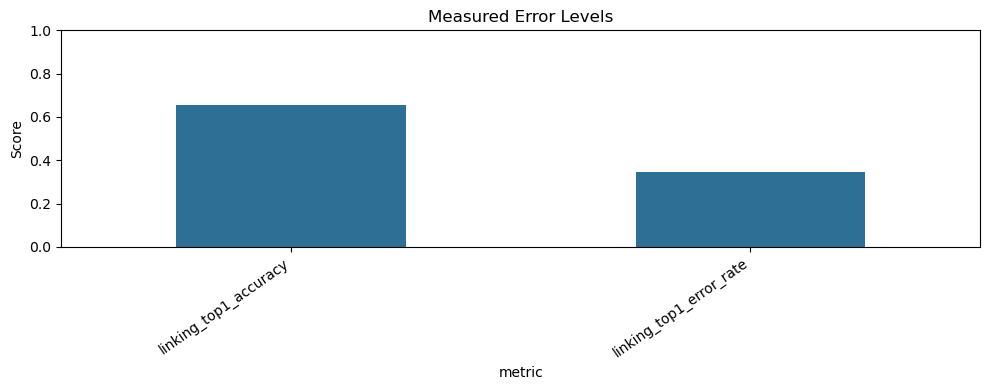

In [ ]:
if error_summary and error_summary.get('spans'):
    span_all = error_summary['spans']['by_split']['all']
    rows = [
        ('span_exact_precision', span_all['exact']['precision']),
        ('span_exact_recall', span_all['exact']['recall']),
        ('span_exact_f1', span_all['exact']['f1']),
        ('span_overlap_precision', span_all['overlap']['precision']),
        ('span_overlap_recall', span_all['overlap']['recall']),
        ('span_overlap_f1', span_all['overlap']['f1']),
        ('linking_top1_accuracy', error_summary['linking']['top1_accuracy']),
    ]
else:
    rows = [
        ('linking_top1_accuracy', error_summary['linking']['top1_accuracy'] if error_summary else 0.0),
        ('linking_top1_error_rate', error_summary['linking']['top1_error_rate'] if error_summary else 0.0),
    ]

df_split = pd.DataFrame(rows, columns=['metric', 'value'])
display(df_split)

ax = df_split.plot(kind='bar', x='metric', y='value', figsize=(10, 4), legend=False, color='#2E6F95')
ax.set_ylim(0, 1)
ax.set_title('Measured Error Levels')
ax.set_ylabel('Score')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

## 2) Linking Difficulty by Divergence

This chart shows where linking fails most often once the mention is already known.

,band,rows,top1_accuracy,top1_error_rate
0,near_canonical,2709,0.6549,0.3451


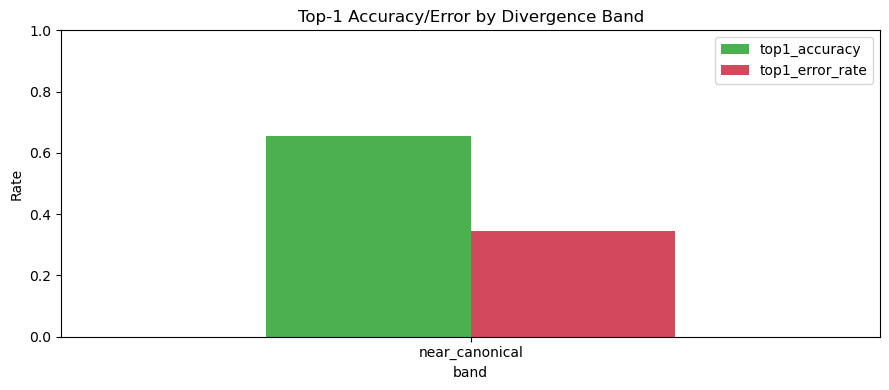

In [ ]:
if error_summary is None:
    print('Run: uv run python analyze_error_levels.py')
else:
    div = pd.DataFrame(error_summary['linking']['divergence_breakdown'])
    display(div)
    ax = div.plot(kind='bar', x='band', y=['top1_accuracy', 'top1_error_rate'], figsize=(9, 4), color=['#4CAF50', '#D1495B'])
    ax.set_ylim(0, 1)
    ax.set_title('Top-1 Accuracy/Error by Divergence Band')
    ax.set_ylabel('Rate')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

## 3) Temporal Prior and Typical Errors

These examples show link errors under the current setup:
- strict `minjaar` / `maxjaar` gating
- attendance-year soft boost (candidate gets a small score bonus if attested in that year)

Use this table to inspect whether remaining errors are due to lexical ambiguity or close-family confusions.


## Diagnostic: Are the gold labels credible?

Some benchmark errors may not be matcher failures — the `patterns` field in the rc3 data
contains raw OCR-extracted text that was associated with a delegate in the resolutions,
which can include:
- genuine spelling variants of that delegate's name ✓
- names of *other* delegates mentioned nearby ✗
- fragments, OCR noise, or multi-person spans ✗

The cell below shows cases where the matcher was **very confident** but wrong.
If the predicted name visually matches the query better than the gold, it is a gold-label problem, not a matcher problem.


In [ ]:

if paths['eval_real'].exists():
    er = pd.read_parquet(paths['eval_real'])

    # Also pull variant_raw from test_real if available
    test_real_path = EVAL_DIR / 'test_real.parquet'
    if test_real_path.exists():
        tr = pd.read_parquet(test_real_path)[['variant_raw', 'variant_norm', 'cons_id_str', 'divergence', 'divergence_band']].copy()
        tr = tr.rename(columns={'cons_id_str': 'cons_id_str_gold'})
        er = er.reset_index(drop=True)
        tr = tr.reset_index(drop=True)
        er = pd.concat([er, tr[['variant_raw', 'variant_norm', 'divergence']]], axis=1)

    diag_cols = [c for c in [
        'variant_raw', 'query_text', 'year',
        'fullname', 'pred_fullname',
        'score_1', 'score_gap_12', 'divergence_band', 'top1_correct'
    ] if c in er.columns]

    wrong = er[~er['top1_correct']].copy()

    print(f'Total errors: {len(wrong)} of {len(er)} ({len(wrong)/len(er):.1%})')
    print()

    # Cases where matcher was very confident but wrong — likely gold label issues
    high_conf_wrong = wrong[wrong['score_1'] >= 0.6].sort_values('score_1', ascending=False)
    print(f'High-confidence wrong (score_1 >= 0.6): {len(high_conf_wrong)} cases')
    print('Inspect: does the query look more like pred_fullname than fullname?')
    display(high_conf_wrong[diag_cols].head(30))


Total errors: 935 of 2709 (34.5%)

High-confidence wrong (score_1 >= 0.6): 350 cases
Inspect: does the query look more like pred_fullname than fullname?


,variant_raw,variant_raw,query_text,year,fullname,pred_fullname,score_1,score_gap_12,divergence_band,top1_correct
1507,berghsma,berghsma,bergsma,1774,"Berchuijs, Tjaard van","Bergsma, Petrus Adrianus",1.1,0.1000,near_canonical,False
58,jordens,jordens,jordens,1795,"Kempenaer, Daniël de","Jordens, Gerrit David",1.1,0.9727,near_canonical,False
1,bigot,bigot,bigot,1750,"Bigot, Charles","Bigot, Frans Adriaan",1.0,0.0000,near_canonical,False
2391,rengers,rengers,rengers,1788,"Rengers, Lamoraal Joachim Johan Juckema van Bu...","Rengers, Pieter Ulbo",1.0,0.0000,near_canonical,False
2420,bergsma,bergsma,bergsma,1781,"Bergsma, Petrus Adrianus","Bergsma, Arjen",1.0,0.0000,near_canonical,False
316,hurgronje,hurgronje,hurgronje,1772,"Verboom, Thomas Dolegius Adriaan","Hurgronje, Willem Isaacsz.",1.0,0.9495,near_canonical,False
407,quarles,quarles,quarles,1768,"Heemskerck, Willem van","Quarles, Lodewijk",1.0,0.3871,near_canonical,False
1165,trip,trip,trip,1766,"Trip, Lucas","Trip, Laurens Adriaan",1.0,0.0000,near_canonical,False
414,hubrecht,hubrecht,hubregt,1780,"Blok, Anthony","Hubrecht, Jan",1.0,0.8065,near_canonical,False
415,baart,baart,baart,1778,"Baert, Adriaan","Baert, Jacob",1.0,0.0000,near_canonical,False


In [ ]:

# How many "outlier" errors look like the matcher is correct and gold is wrong?
if paths['eval_real'].exists() and (EVAL_DIR / 'test_real.parquet').exists():
    er = pd.read_parquet(paths['eval_real'])
    tr = pd.read_parquet(EVAL_DIR / 'test_real.parquet')[['variant_raw', 'cons_id_str']].reset_index(drop=True)
    # avoid duplicate columns if variant_raw already present
    for col in ['variant_raw', 'cons_id_str']:
        if col in er.columns:
            tr = tr.drop(columns=[col])
    er = pd.concat([er.reset_index(drop=True), tr], axis=1)

    wrong = er[~er['top1_correct']].copy()

    def pred_surname(name):
        if not isinstance(name, str) or not name.strip():
            return ''
        return name.split(',')[0].strip().lower() if ',' in name else name.strip().lower()

    wrong['pred_surname'] = wrong['pred_fullname'].map(pred_surname)
    raw_series = wrong['variant_raw'].astype(str).str.strip().str.lower()
    wrong['raw_lower'] = raw_series
    wrong['raw_in_pred_name'] = wrong.apply(
        lambda r: r['raw_lower'] in r['pred_surname'] or r['pred_surname'] in r['raw_lower'],
        axis=1
    )

    suspicious = wrong[wrong['raw_in_pred_name']]
    print(f'Suspicious gold labels (variant_raw matches pred delegate name): {len(suspicious)} of {len(wrong)} errors ({len(suspicious)/len(wrong):.1%})')
    print()
    print('These are cases where the rc3 patterns field likely listed co-attending delegates,')
    print('not spelling variants of the gold delegate.')
    print()

    show = [c for c in ['variant_raw', 'query_text', 'fullname', 'pred_fullname', 'score_1', 'divergence_band'] if c in wrong.columns]
    display(suspicious[show].head(20))


Suspicious gold labels (variant_raw matches pred delegate name): 328 of 935 errors (35.1%)

These are cases where the rc3 patterns field likely listed co-attending delegates,
not spelling variants of the gold delegate.



,variant_raw,query_text,fullname,pred_fullname,score_1,divergence_band
1,bigot,bigot,"Bigot, Charles","Bigot, Frans Adriaan",1.0000,near_canonical
6,van wassenaer twickel,van wassenaar twikel,"Wassenaer Obdam, Carel George van","Wassenaer, Frederik Hendrik van",0.7880,near_canonical
7,van wassenaertwickel,van wassenaartwikel,"Wassenaer Obdam, Carel George van","Wassenaer, Carel Lodewijk van",0.4645,near_canonical
8,e van wassenaer twickel,e van wassenaar twikel,"Wassenaer Obdam, Carel George van","Wassenaer, Carel Lodewijk van",0.7824,near_canonical
9,van wassenaer twickell,van wassenaar twikell,"Wassenaer Obdam, Carel George van","Wassenaer, Frederik Hendrik van",0.7718,near_canonical
10,du tour,du tour,"Tour van Warmenhuisen, Jacob Adriaan du","Tour, David Constantijn du",0.9199,near_canonical
13,l rengers,l rengers,"Rengers, Lodewijk","Rengers, Lamoraal Albertus Aemilius",0.9815,near_canonical
16,van schwartzenberg en hohenlansberg,van skhwartzenberg en hohenlansberg,"Schwartzenberg en Hohenlansberg, Wilco Holding...","Schwartzenberg en Hohenlansberg, Michaël Onuph...",0.9555,near_canonical
23,de blocq van kuffeler,de blokq van kuffeler,"Bangma, Tjalling Oenes","Kuffeler, Jacob Jan de Blocq van",0.9273,near_canonical
36,van haren,van haren,"Haren, Willem van","Haren, Adam Ernst van",0.9395,near_canonical


In [ ]:
if paths['eval_real'].exists():
    eval_real = pd.read_parquet(paths['eval_real'])
    cols = [
        c for c in [
            'query_text', 'year', 'fullname', 'pred_fullname',
            'score_1', 'score_2', 'score_gap_12', 'top1_correct'
        ]
        if c in eval_real.columns
    ]
    display(eval_real[cols].head(20))

    if 'top1_correct' in eval_real.columns:
        wrong = eval_real[~eval_real['top1_correct']].copy()
        display(wrong[cols].head(20))
else:
    print('Missing eval_real.parquet. Run: uv run python build_linking_benchmark.py')

,query_text,year,fullname,pred_fullname,score_1,score_2,score_gap_12,top1_correct
0,vegilin,1750,"Vegelin van Claerbergen, Johan","Vegelin van Claerbergen, Johan",0.2215,0.2215,0.0000,True
1,bigot,1750,"Bigot, Charles","Bigot, Frans Adriaan",1.0000,1.0000,0.0000,False
2,brgot,1750,"Bigot, Charles","Bigot, Charles",0.3060,0.3060,0.0000,True
3,van skhwartzenberg,1750,"Schwartzenberg en Hohenlansberg, Georg Wolfgan...","Schwartzenberg en Hohenlansberg, Georg Wolfgan...",0.5965,0.5965,0.0000,True
4,van sebwartzenberg,1750,"Schwartzenberg en Hohenlansberg, Georg Wolfgan...","Schwartzenberg en Hohenlansberg, Michaël Onuph...",0.3558,0.3558,0.0000,False
5,van skhwartvenberg,1750,"Schwartzenberg en Hohenlansberg, Georg Wolfgan...","Schwartzenberg en Hohenlansberg, Michaël Onuph...",0.3476,0.3476,0.0000,False
6,van wassenaar twikel,1750,"Wassenaer Obdam, Carel George van","Wassenaer, Frederik Hendrik van",0.7880,0.7880,0.0000,False
7,van wassenaartwikel,1750,"Wassenaer Obdam, Carel George van","Wassenaer, Carel Lodewijk van",0.4645,0.4645,0.0000,False
8,e van wassenaar twikel,1750,"Wassenaer Obdam, Carel George van","Wassenaer, Carel Lodewijk van",0.7824,0.7824,0.0000,False
9,van wassenaar twikell,1750,"Wassenaer Obdam, Carel George van","Wassenaer, Frederik Hendrik van",0.7718,0.7718,0.0000,False


,query_text,year,fullname,pred_fullname,score_1,score_2,score_gap_12,top1_correct
1,bigot,1750,"Bigot, Charles","Bigot, Frans Adriaan",1.0000,1.0000,0.0000,False
4,van sebwartzenberg,1750,"Schwartzenberg en Hohenlansberg, Georg Wolfgan...","Schwartzenberg en Hohenlansberg, Michaël Onuph...",0.3558,0.3558,0.0000,False
5,van skhwartvenberg,1750,"Schwartzenberg en Hohenlansberg, Georg Wolfgan...","Schwartzenberg en Hohenlansberg, Michaël Onuph...",0.3476,0.3476,0.0000,False
6,van wassenaar twikel,1750,"Wassenaer Obdam, Carel George van","Wassenaer, Frederik Hendrik van",0.7880,0.7880,0.0000,False
7,van wassenaartwikel,1750,"Wassenaer Obdam, Carel George van","Wassenaer, Carel Lodewijk van",0.4645,0.4645,0.0000,False
8,e van wassenaar twikel,1750,"Wassenaer Obdam, Carel George van","Wassenaer, Carel Lodewijk van",0.7824,0.7824,0.0000,False
9,van wassenaar twikell,1750,"Wassenaer Obdam, Carel George van","Wassenaer, Frederik Hendrik van",0.7718,0.7718,0.0000,False
10,du tour,1750,"Tour van Warmenhuisen, Jacob Adriaan du","Tour, David Constantijn du",0.9199,0.5100,0.4099,False
13,l rengers,1750,"Rengers, Lodewijk","Rengers, Lamoraal Albertus Aemilius",0.9815,0.9815,0.0000,False
14,van skhwartzenberg,1750,"Schwartzenberg en Hohenlansberg, Michaël Onuph...","Schwartzenberg en Hohenlansberg, Georg Wolfgan...",0.5965,0.5965,0.0000,False


In [ ]:
import re

def infer_pattern_type(text: str) -> str:
    s = (text or '').strip().lower()
    if not s:
        return 'empty'
    has_particle = bool(re.search(r'\b(van|de|den|der|te|tot|ten)\b', s))
    has_hyphen = '-' in s
    token_count = len([t for t in re.split(r'\s+', s) if t])
    if token_count == 1:
        base = 'single_token'
    elif token_count == 2:
        base = 'two_token'
    elif token_count >= 3:
        base = 'multi_token'
    else:
        base = 'other'
    if has_particle:
        base += '+particle'
    if has_hyphen:
        base += '+hyphen'
    return base

if paths['eval_real'].exists():
    eval_real = pd.read_parquet(paths['eval_real']).copy()
    eval_real['pattern_type'] = eval_real['query_text'].map(infer_pattern_type)
    eval_real['high_conf_wrong'] = (~eval_real['top1_correct']) & (eval_real['score_1'] >= 0.5)

    view_cols = [
        c for c in [
            'query_text', 'pattern_type', 'year', 'fullname', 'pred_fullname',
            'score_1', 'score_2', 'score_gap_12', 'divergence_band',
            'top1_correct', 'high_conf_wrong'
        ]
        if c in eval_real.columns
    ]

    print('Correct examples (high score):')
    display(
        eval_real[eval_real['top1_correct']]
        .sort_values(['score_1', 'score_gap_12'], ascending=[False, False])
        [view_cols]
        .head(20)
    )

    print('Incorrect examples (high score, likely overconfident mismatches):')
    display(
        eval_real[~eval_real['top1_correct']]
        .sort_values(['score_1', 'score_gap_12'], ascending=[False, False])
        [view_cols]
        .head(20)
    )

    print('Incorrect examples (low score, likely ambiguous/noisy mentions):')
    display(
        eval_real[~eval_real['top1_correct']]
        .sort_values(['score_1', 'score_gap_12'], ascending=[True, True])
        [view_cols]
        .head(20)
    )

    pattern_summary = (
        eval_real.groupby('pattern_type', dropna=False)['top1_correct']
        .agg(['count', 'mean'])
        .rename(columns={'mean': 'top1_accuracy'})
        .sort_values('count', ascending=False)
    )
    print('Pattern-type summary:')
    display(pattern_summary.head(15))
else:
    print('Missing eval_real.parquet. Run: uv run python build_linking_benchmark.py')

Correct examples (high score):


,query_text,pattern_type,year,fullname,pred_fullname,score_1,score_2,score_gap_12,divergence_band,top1_correct,high_conf_wrong
2541,jordens,single_token,1795,"Jordens, Gerrit David","Jordens, Gerrit David",1.1,0.1273,0.9727,near_canonical,True,False
331,preuit,single_token,1780,"Preuijt, Jan","Preuijt, Jan",1.0,0.0375,0.9625,near_canonical,True,False
1843,nuien,single_token,1750,"Nuijen, Anthonij","Nuijen, Anthonij",1.0,0.0587,0.9413,near_canonical,True,False
510,upmijer,single_token,1762,"Upmeijer, H.J.","Upmeijer, H.J.",1.0,0.0594,0.9406,near_canonical,True,False
1787,potgieter,single_token,1724,"Potgieter, Nicolaas","Potgieter, Nicolaas",1.0,0.0687,0.9313,near_canonical,True,False
2183,thibaut,single_token,1772,"Thibaut, Wilhem","Thibaut, Wilhem",1.0,0.0688,0.9312,near_canonical,True,False
1545,lutteken,single_token,1722,"Lutteken, Bartholt","Lutteken, Bartholt",1.0,0.0690,0.9310,near_canonical,True,False
1558,keiser,single_token,1782,"Keiser, Jan Harmen","Keiser, Jan Harmen",1.0,0.0701,0.9299,near_canonical,True,False
126,hallinkg,single_token,1726,"Hallincg, Adriaan","Hallincg, Adriaan",1.0,0.0709,0.9291,near_canonical,True,False
104,griffioen,single_token,1779,"Griffioen, Willem","Griffioen, Willem",1.0,0.0717,0.9283,near_canonical,True,False


Incorrect examples (high score, likely overconfident mismatches):


,query_text,pattern_type,year,fullname,pred_fullname,score_1,score_2,score_gap_12,divergence_band,top1_correct,high_conf_wrong
58,jordens,single_token,1795,"Kempenaer, Daniël de","Jordens, Gerrit David",1.1,0.1273,0.9727,near_canonical,False,True
1507,bergsma,single_token,1774,"Berchuijs, Tjaard van","Bergsma, Petrus Adrianus",1.1,1.0000,0.1000,near_canonical,False,True
316,hurgronje,single_token,1772,"Verboom, Thomas Dolegius Adriaan","Hurgronje, Willem Isaacsz.",1.0,0.0505,0.9495,near_canonical,False,True
1421,lewe,single_token,1750,"Otters, Oswald","Lewe, Evert Joost",1.0,0.0944,0.9056,near_canonical,False,True
506,lestevenon,single_token,1785,"Citters, Jacob Verheye van","Lestevenon, Willem Anne",1.0,0.1220,0.8780,near_canonical,False,True
518,jordens,single_token,1736,"Bempden, Gilles van den","Jordens, Rudolf",1.0,0.1273,0.8727,near_canonical,False,True
2168,gerlakius,single_token,1732,"Slichers, Wichbolt Anthonisz.","Gerlacius, Tjaard Adriaan",1.0,0.1479,0.8521,near_canonical,False,True
677,rouse,single_token,1710,"Jonge van Campensnieuwland, Bonifacius de","Rouse, Everhard",1.0,0.1509,0.8491,near_canonical,False,True
786,huigens,single_token,1762,"Fockink, Jacob Joan","Huyghens, Willem",1.0,0.1633,0.8367,near_canonical,False,True
861,geelvink,single_token,1772,"Vestrinck, Abraham","Geelvinck, Nicolaas",1.0,0.1688,0.8312,near_canonical,False,True


Incorrect examples (low score, likely ambiguous/noisy mentions):


,query_text,pattern_type,year,fullname,pred_fullname,score_1,score_2,score_gap_12,divergence_band,top1_correct,high_conf_wrong
439,vumeulen,single_token,1704,"Heinsius, Anthonie","Zuylen van Nievelt, Gerrit Willem van",0.0694,0.0675,0.0019,near_canonical,False,False
447,onderwavr,single_token,1704,"Heinsius, Anthonie","Borch van Verwolde, Allard Philip Reinier Care...",0.0721,0.0524,0.0197,near_canonical,False,False
441,vemeulen,single_token,1704,"Heinsius, Anthonie","Zuylen van Nievelt, Gerrit Willem van",0.0786,0.0764,0.0022,near_canonical,False,False
448,onderwater,single_token,1704,"Heinsius, Anthonie","Schatter, Pieter",0.0862,0.0720,0.0142,near_canonical,False,False
442,vermeulen,single_token,1704,"Heinsius, Anthonie","Verstegen, Peter",0.0897,0.0790,0.0107,near_canonical,False,False
446,onlerwater,single_token,1704,"Heinsius, Anthonie","Schatter, Pieter",0.0985,0.0933,0.0052,near_canonical,False,False
135,duvenvoirde,single_token,1692,"Wassenaer, Jacob van","Lamsweerde, Gerardus Wilhelmus Josephus van",0.1022,0.0961,0.0061,near_canonical,False,False
1078,vai spanbroek,two_token,1713,"Geel, Cornelis van","Broeckhuysen tot de Grote Wede, Wolter Jan van",0.1102,0.0900,0.0202,near_canonical,False,False
1076,spanbroek,single_token,1713,"Geel, Cornelis van","Broeckhuysen tot de Grote Wede, Wolter Jan van",0.1133,0.0867,0.0266,near_canonical,False,False
1077,van spanbroek,two_token+particle,1713,"Geel, Cornelis van","Broeckhuysen tot de Grote Wede, Wolter Jan van",0.1221,0.1145,0.0076,near_canonical,False,False


Pattern-type summary:


,count,top1_accuracy
pattern_type,,
single_token,987,0.730496
multi_token+particle,637,0.587127
two_token+particle,635,0.585827
two_token,260,0.642308
multi_token,60,0.650000
multi_token+particle+hyphen,32,0.750000
single_token+hyphen,28,0.821429
two_token+particle+hyphen,26,0.846154
two_token+hyphen,20,0.800000


## 3b) Correct vs Incorrect Name-Pattern Examples

These tables show concrete top-1 outcomes with a lightweight pattern label inferred from the query text.

Interpretation:
- `pattern_type` helps identify whether errors cluster in specific mention shapes.
- `high_conf_wrong` means the model was confident (`score_1` high) but still picked the wrong delegate.

,fullname,pred_fullname,count
0,"Utenhoven, Jacob van","Utenhove, Reynier van",34
1,"Citters, Jacob Verheye van","Lestevenon, Willem Anne",13
2,"Greven, Albert sr.","Sloet tot Warmelo, Johan Albert Gabriel",10
3,"Schwartzenberg en Hohenlansberg, Georg Wolfgan...","Schwartzenberg en Hohenlansberg, Michaël Onuph...",9
4,"Fockink, Jacob Joan","Citters, Wilhem van",8
5,"Brakell, Philip Jacob","Brakell, Jacob Derk van",8
6,"Wassenaer Obdam, Carel George van","Wassenaer, Carel Lodewijk van",7
7,"Reede, Godert Adriaan van","Reede tot Renswoude, Frederik van",7
8,"Hasselt, Johan Coenraat van","Haersolte, Johan Willem Simon van",7
9,"Sirtema van Grovestins, Willem Anne","Sirtema van Grovestins, Jan",7


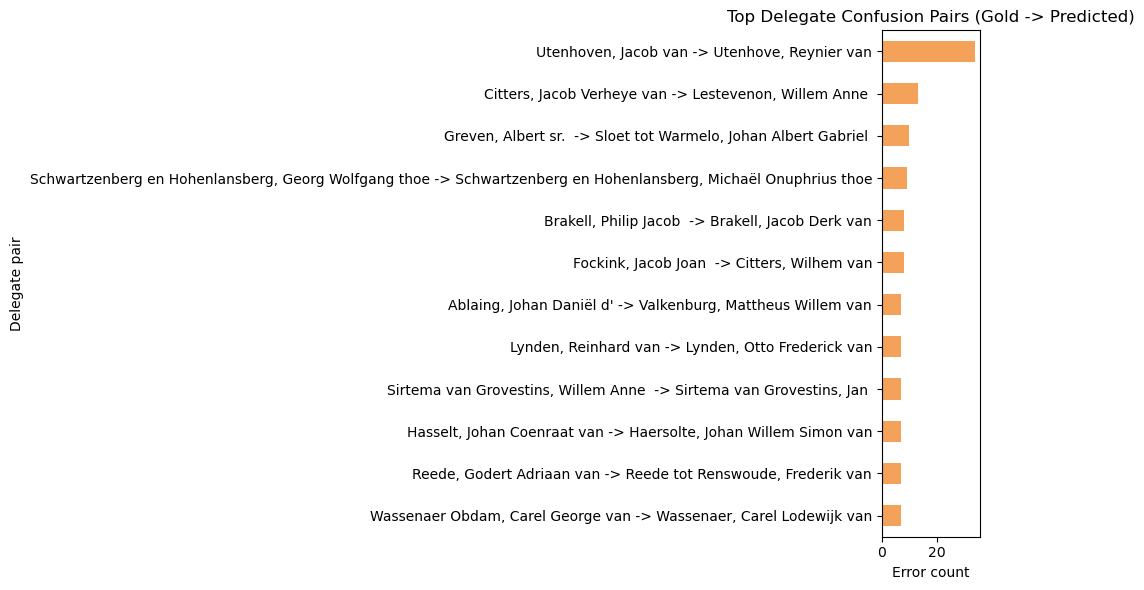

In [ ]:
if paths['confusion_pairs'].exists():
    confusion_pairs = pd.read_csv(paths['confusion_pairs'])
    display(confusion_pairs.head(20))

    top = confusion_pairs.head(12).copy()
    top['pair'] = top['fullname'].astype(str) + ' -> ' + top['pred_fullname'].astype(str)
    ax = top.sort_values('count').plot(kind='barh', x='pair', y='count', figsize=(10, 6), legend=False, color='#F4A259')
    ax.set_title('Top Delegate Confusion Pairs (Gold -> Predicted)')
    ax.set_xlabel('Error count')
    ax.set_ylabel('Delegate pair')
    plt.tight_layout()
    plt.show()
else:
    print('Missing linking_confusion_pairs.csv. Re-run linking benchmark script.')

## 4) Family-Level Confusion Matrix

,utenhoven,schwartzenberg en hohenlansberg,lynden,heinsius,wassenaer,citters,reede,alberda,greven,heeckeren,...,aylva,utenhove,haersolte,tamminga,lestevenon,valkenburg,zuylen van nievelt,rengers,vegelin van claerbergen,bleyswijk
gold_family,,,,,,,,,,,,,,,,,,,,,
utenhoven,3,0,0,0,0,0,0,0,0,0,...,0,34,0,0,0,0,0,0,0,0
schwartzenberg en hohenlansberg,0,27,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
lynden,0,0,17,0,0,0,0,0,0,0,...,0,0,0,0,0,2,0,0,0,0
heinsius,0,0,0,14,0,0,0,0,0,0,...,0,0,0,0,0,0,3,0,0,0
wassenaer,0,1,0,0,13,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
citters,0,0,0,0,0,2,0,0,0,0,...,0,0,0,0,13,0,0,0,0,0
reede,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
alberda,0,0,0,0,0,0,0,20,0,0,...,0,0,0,0,0,0,0,0,0,0
greven,0,0,0,0,0,0,0,0,2,0,...,0,0,0,0,0,0,0,0,0,0


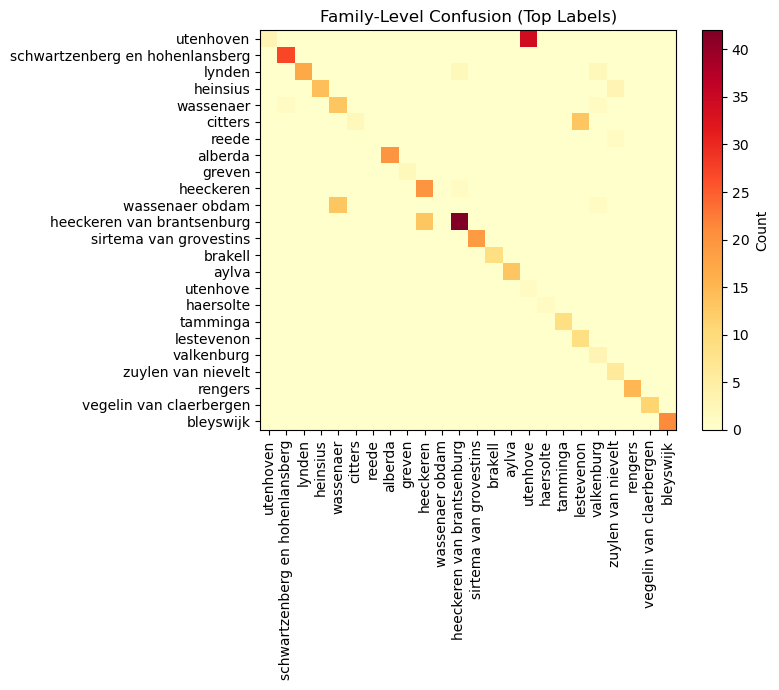

In [ ]:
if paths['confusion_matrix_family'].exists():
    cm = pd.read_csv(paths['confusion_matrix_family'], index_col=0)
    display(cm.head(10))

    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(cm.values, cmap='YlOrRd', aspect='auto')
    ax.set_title('Family-Level Confusion (Top Labels)')
    ax.set_xticks(range(len(cm.columns)))
    ax.set_xticklabels(cm.columns, rotation=90)
    ax.set_yticks(range(len(cm.index)))
    ax.set_yticklabels(cm.index)
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label('Count')
    plt.tight_layout()
    plt.show()
else:
    print('Missing linking_confusion_matrix_family.csv. Re-run linking benchmark script.')

## 5) Optional Span-Level Evaluation

When you have predicted spans, run this in terminal first:

`uv run python analyze_error_levels.py --predicted-spans <pred_spans.parquet> --gold-spans data/eval/per_span_gold_validate.parquet`

Then re-run this notebook to include span precision/recall/F1 next to linking metrics.

## 6) Structured KWIC Evaluation Pipeline (A-F)

This section implements the intended workflow:

1. Fetch hoedanigheden pattern with KWIC context
2. Infer whether context indicates one or multiple persons
3. Detect delegate-likely indications
4. Reconstruct person span candidates from KWIC context
5. Compare reconstructed spans against gold spans
6. Compare KWIC-derived results with NER output (if available)

Notes:
- This section is extraction-first (KWIC -> span reconstruction -> matching).
- NER comparison is optional and auto-enabled when a NER output file is found.


In [2]:
import importlib.util
import re
from pathlib import Path

import pandas as pd

from preprocess import clean_span

# -------------------------
# Stage A: Load & align inputs
# -------------------------
ROOT = Path.cwd()
EVAL_DIR = ROOT / 'data' / 'eval'

gold_paths = [EVAL_DIR / 'per_span_gold_validate.parquet', EVAL_DIR / 'per_span_gold_test.parquet']
gold_frames = [pd.read_parquet(p) for p in gold_paths if p.exists()]
gold_spans = pd.concat(gold_frames, ignore_index=True) if gold_frames else pd.DataFrame()

kwic_path = ROOT / 'data' / 'kwic_index.jsonl'
kwic = pd.read_json(kwic_path, lines=True) if kwic_path.exists() else pd.DataFrame()

# Optional NER output discovery (non-blocking)
ner_candidates = []
for pat in ['*ner*.parquet', '*ner*.jsonl', '*flair*.parquet', '*flair*.jsonl', '*pred*.parquet']:
    ner_candidates.extend((ROOT / 'data').glob(pat))
    ner_candidates.extend(EVAL_DIR.glob(pat))
ner_candidates = sorted(set(ner_candidates))
ner_path = ner_candidates[0] if ner_candidates else None

print('Stage A - Input status')
print(f'  Gold spans rows: {len(gold_spans)}')
print(f'  KWIC rows: {len(kwic)}')
print(f'  NER file found: {ner_path if ner_path else "None"}')

if not gold_spans.empty and 'label' in gold_spans.columns:
    gold_per = gold_spans[gold_spans['label'].astype(str).str.upper() == 'PER'].copy()
else:
    gold_per = gold_spans.copy()

# -------------------------
# Stage B: HOE-derived cues from actual files
# -------------------------
def _load_kws_hoe_module(path: Path):
    spec = importlib.util.spec_from_file_location('kws_hoe_runtime', path)
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)  # type: ignore[union-attr]
    return mod

kws_hoe_path = ROOT / 'data' / 'kws_hoe.py'
perscatrep_path = ROOT / 'data' / 'perscatrep.tsv'

HOE_CANONICAL_TERMS = set()
DELLPAT_RAW = []
if kws_hoe_path.exists():
    mod = _load_kws_hoe_module(kws_hoe_path)
    for dict_name in ['kws_qual', 'kw_edelen', 'kw_kerk', 'kw_ambt', 'kw_beroep', 'kw_pol', 'kw_id', 'kw_rest', 'kw_new', 'kw_zlast']:
        d = getattr(mod, dict_name, None)
        if isinstance(d, dict):
            HOE_CANONICAL_TERMS.update(str(v).strip().lower() for v in d.values() if str(v).strip())
    maybe_dellpat = getattr(mod, 'dellpat', [])
    if isinstance(maybe_dellpat, list):
        DELLPAT_RAW = [str(p) for p in maybe_dellpat if str(p).strip()]

DELLPAT_PATTERNS = []
for pat in DELLPAT_RAW:
    try:
        DELLPAT_PATTERNS.append(re.compile(pat, re.IGNORECASE))
    except re.error:
        pass

PERSCATREP_TERMS = set()
if perscatrep_path.exists():
    pc = pd.read_csv(perscatrep_path, sep='\t', dtype=str)
    if 'norm_term' in pc.columns:
        PERSCATREP_TERMS = set(pc['norm_term'].dropna().astype(str).str.strip().str.lower())

NON_PERSON_LEXICON = HOE_CANONICAL_TERMS.union(PERSCATREP_TERMS).union({
    'missive', 'resolutie', 'requeste', 'copie', 'staat', 'vergaderinge',
    'hoog mogende', 'ho mog', 'raad', 'hof', 'memoriel', 'brief', 'extract',
})

TITLE_OR_ROLE_TOKENS = {
    'heer', 'heeren', 'mr', 'jhr', 'baron', 'graaf', 'graavin', 'jonkheer', 'jonkvrouw',
    'ambassadeur', 'gezant', 'envoye', 'gedeputeerde', 'gedeputeerden',
    'kapitein', 'kolonel', 'generaal', 'commissaris', 'resident', 'minister'
}

if not kwic.empty:
    kwic = kwic.copy()
    kwic['left_context'] = kwic.get('left_context', '').fillna('').astype(str)
    kwic['span_text'] = kwic.get('span_text', '').fillna('').astype(str)
    kwic['right_context'] = kwic.get('right_context', '').fillna('').astype(str)
    kwic['canonical'] = kwic.get('canonical', '').fillna('').astype(str)
    kwic['category'] = kwic.get('category', '').fillna('').astype(str)
    kwic['kwic_text'] = kwic['left_context'] + ' ' + kwic['span_text'] + ' ' + kwic['right_context']

    kwic['has_hoedanigheid_cue'] = (
        kwic['category'].str.startswith('person_')
        | kwic['canonical'].str.lower().isin(HOE_CANONICAL_TERMS)
        | kwic['canonical'].str.lower().isin(PERSCATREP_TERMS)
    )

    multi_markers = ['de heeren', 'de heren', 'gedeputeerden', 'afgezanten', 'commissarissen', 'envoyes', 'ambassadeurs']
    single_markers = ['de heer', 'den heer', 'monsieur', 'jhr', 'baron', 'graaf']

    lower_text = kwic['kwic_text'].str.lower()
    kwic['single_person_signal'] = lower_text.apply(lambda s: any(m in s for m in single_markers))
    kwic['multi_person_signal'] = lower_text.apply(lambda s: any(m in s for m in multi_markers))

    def infer_person_count(row):
        if row['multi_person_signal'] and not row['single_person_signal']:
            return 'multi'
        if row['single_person_signal'] and not row['multi_person_signal']:
            return 'single'
        if str(row['category']).startswith('person_'):
            return 'single'
        return 'unknown'

    kwic['person_count_hint'] = kwic.apply(infer_person_count, axis=1)
else:
    kwic['has_hoedanigheid_cue'] = []
    kwic['single_person_signal'] = []
    kwic['multi_person_signal'] = []
    kwic['person_count_hint'] = []

print('\nStage B - KWIC cue statistics (HOE-derived)')
print(f'  Loaded dellpat regex patterns: {len(DELLPAT_PATTERNS)}')
if not kwic.empty:
    print(kwic[['has_hoedanigheid_cue', 'person_count_hint']].value_counts().head(12))
else:
    print('  No KWIC data found.')

# -------------------------
# Stage C + D: Delegate indication and span reconstruction
# -------------------------
NAME_RE = re.compile(
    r"\b(?:[A-Z][a-z]{1,}(?:['-][A-Z][a-z]+)?(?:\s+(?:van|de|den|der|ter|te|tot|vanden|vander))?\s+)?"
    r"[A-Z][a-z]{1,}(?:['-][A-Z][a-z]+)?(?:\s+[A-Z][a-z]{1,}(?:['-][A-Z][a-z]+)?){0,2}\b"
)

DELEGATE_HINT_CUES = [
    'gedeputeerde', 'gedeputeerden', 'gecommitteerde', 'gecomitteerden',
    'haar hoog mogende', 'h.h.m.', 'griffier', 'president',
    'heer', 'heeren', 'heren', 'raadpensionaris', 'staten-generaal',
]


def _matches_dellpat(text: str) -> bool:
    if not text:
        return False
    return any(p.search(text) is not None for p in DELLPAT_PATTERNS)


def _is_non_person_term(candidate: str, row_text_lower: str) -> bool:
    c = clean_span(candidate).strip().lower()
    if not c:
        return True

    if _matches_dellpat(c):
        return True

    if c in NON_PERSON_LEXICON:
        return True

    for bad in ['resolut', 'missiv', 'request', 'copie', 'extract', 'memor']:
        if c.startswith(bad):
            return True

    tokens = [t for t in c.split() if t]

    if tokens and all(t in TITLE_OR_ROLE_TOKENS for t in tokens):
        return True

    if len(tokens) == 1:
        tok = tokens[0]
        if tok in TITLE_OR_ROLE_TOKENS or tok in NON_PERSON_LEXICON:
            return True
        context_person_hints = ['heer', 'mr', 'jhr', 'baron', 'graaf', 'ambassadeur', 'gezant', 'gedeputeerde', 'kapitein', 'kolonel']
        if not any(h in row_text_lower for h in context_person_hints):
            return True

    return False


def reconstruct_name_spans_from_kwic(row):
    text = row.get('kwic_text', '')
    text_lower = str(text).lower()
    candidates = NAME_RE.findall(text)
    out = []
    seen = set()

    for cand in candidates:
        c = cand.strip(' ,.;:()[]')
        key = clean_span(c).lower()
        if len(key) < 4:
            continue
        if key in seen:
            continue
        if _is_non_person_term(c, text_lower):
            continue
        seen.add(key)
        out.append(c)

    return out


if not kwic.empty:
    kwic['delegate_hint'] = kwic['kwic_text'].str.lower().apply(lambda s: any(c in s for c in DELEGATE_HINT_CUES))

    kwic_focus = kwic[kwic['has_hoedanigheid_cue']].copy()
    kwic_focus['reconstructed_spans'] = kwic_focus.apply(reconstruct_name_spans_from_kwic, axis=1)
    kwic_focus['reconstructed_count'] = kwic_focus['reconstructed_spans'].apply(len)

    reconstructed = (
        kwic_focus[['kwic_text', 'person_count_hint', 'has_hoedanigheid_cue', 'delegate_hint', 'reconstructed_spans', 'canonical', 'category']]
        .explode('reconstructed_spans')
        .dropna(subset=['reconstructed_spans'])
        .rename(columns={'reconstructed_spans': 'reconstructed_span'})
    )
    reconstructed['reconstructed_span_clean'] = reconstructed['reconstructed_span'].apply(clean_span)
else:
    reconstructed = pd.DataFrame(columns=['kwic_text', 'person_count_hint', 'has_hoedanigheid_cue', 'delegate_hint', 'reconstructed_span', 'reconstructed_span_clean', 'canonical', 'category'])

print('\nStage C/D - Reconstruction status (HOE-filtered + dellpat)')
if not kwic.empty:
    total_rows = len(kwic)
    focus_rows = int(kwic['has_hoedanigheid_cue'].sum())
    print(f'  KWIC rows total: {total_rows}')
    print(f'  KWIC rows with HOE/person cue: {focus_rows}')
print(f'  Total reconstructed span rows: {len(reconstructed)}')
if len(reconstructed):
    display(reconstructed[['reconstructed_span', 'canonical', 'category', 'person_count_hint', 'delegate_hint']].head(12))


Stage A - Input status
  Gold spans rows: 793
  KWIC rows: 7743
  NER file found: /Users/rikhoekstra/develop/republic_ner_matching/data/eval/ner_legacy_per_spans.parquet

Stage B - KWIC cue statistics (HOE-derived)
  Loaded dellpat regex patterns: 136
has_hoedanigheid_cue  person_count_hint
True                  single               7139
False                 unknown               425
True                  multi                 120
False                 single                 52
                      multi                   7
Name: count, dtype: int64

Stage C/D - Reconstruction status (HOE-filtered + dellpat)
  KWIC rows total: 7743
  KWIC rows with HOE/person cue: 7259
  Total reconstructed span rows: 207223


Stage A - Input status
  Gold spans rows: 793
  KWIC rows: 7743
  NER file found: /Users/rikhoekstra/develop/republic_ner_matching/data/eval/ner_legacy_per_spans.parquet

Stage B - KWIC cue statistics (HOE-derived)
  Loaded dellpat regex patterns: 136
has_hoedanigheid_cue  person_count_hint
True                  single               7139
False                 unknown               425
True                  multi                 120
False                 single                 52
                      multi                   7
Name: count, dtype: int64

Stage C/D - Reconstruction status (HOE-filtered + dellpat)
  KWIC rows total: 7743
  KWIC rows with HOE/person cue: 7259
  Total reconstructed span rows: 207223


,reconstructed_span,canonical,category,person_count_hint,delegate_hint
0,Lieutetenant Collonel,kolonel,person_profession,single,True
0,Commandeur van Viissingen,kolonel,person_profession,single,True
0,Doorlugtige Hoogheid,kolonel,person_profession,single,True
0,Commandement van Vlissingen,kolonel,person_profession,single,True
0,Lieutenant Collonel,kolonel,person_profession,single,True
0,Commandeur de Casembroot,kolonel,person_profession,single,True
0,Major Beek,kolonel,person_profession,single,True
1,Lieutetenant Collonel,commandant,person_profession,single,True
1,Commandeur van Viissingen,commandant,person_profession,single,True
1,Doorlugtige Hoogheid,commandant,person_profession,single,True


In [3]:
import pickle
import numpy as np

from match import build_store, build_attendance_year_index, match_ner

# -------------------------
# Stage E: Evaluate against gold (extraction + linking proxy)
# -------------------------
ref = pd.read_parquet(ROOT / 'data' / 'delegates_reference.parquet')
store = build_store(ref)

attendance_paths = [
    '/Users/rikhoekstra/develop/republic_delegates_data/1705_1795/supplementary/attendance_1705_1795.parquet',
    '/Users/rikhoekstra/develop/republic_delegates_data/1610_1630/supplementary/attendance_1610_1630.parquet',
]
attendance_paths = [p for p in attendance_paths if Path(p).exists()]
attendance_years = build_attendance_year_index(attendance_paths) if attendance_paths else None

# Prepare reconstructed mentions for matching.
# KWIC rows have no reliable year in this file; use broad tolerance to avoid over-penalization.
if not reconstructed.empty:
    kwic_match_input = pd.DataFrame({
        'tag_text': reconstructed['reconstructed_span_clean'].fillna('').astype(str),
        'year': np.repeat(1750, len(reconstructed)),
    })
    kwic_match_results = match_ner(
        store,
        kwic_match_input,
        top_k=5,
        year_tolerance=300,
        min_score=0.1,
        attendance_years_by_id=attendance_years,
        attendance_boost=0.1,
    )
    reconstructed = reconstructed.reset_index(drop=True)
    kwic_eval = pd.concat([reconstructed, kwic_match_results[['cand_1', 'score_1']]], axis=1)
else:
    kwic_eval = pd.DataFrame(columns=['reconstructed_span', 'reconstructed_span_clean', 'cand_1', 'score_1'])

# Gold span normalization for extraction comparison
if not gold_per.empty and 'span_text' in gold_per.columns:
    gold_per = gold_per.copy()
    gold_per['gold_span_clean'] = gold_per['span_text'].astype(str).apply(clean_span)
else:
    gold_per = pd.DataFrame(columns=['gold_span_clean'])

kwic_set = set(kwic_eval['reconstructed_span_clean'].dropna().astype(str))
gold_set = set(gold_per['gold_span_clean'].dropna().astype(str))

if kwic_set and gold_set:
    tp = len(kwic_set.intersection(gold_set))
    precision = tp / len(kwic_set)
    recall = tp / len(gold_set)
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
else:
    tp = 0
    precision = 0.0
    recall = 0.0
    f1 = 0.0

print('Stage E - Gold comparison')
print(f'  Gold unique PER spans: {len(gold_set)}')
print(f'  KWIC reconstructed unique spans: {len(kwic_set)}')
print(f'  Span overlap TP: {tp}')
print(f'  Span precision: {precision:.3f}')
print(f'  Span recall: {recall:.3f}')
print(f'  Span F1: {f1:.3f}')

if not kwic_eval.empty:
    coverage = (kwic_eval['score_1'] > 0).mean()
    print(f'  Linking coverage (score_1 > 0): {coverage:.3f}')

    # Consistency: for identical reconstructed spans, how often the same top candidate appears.
    consistency_rows = []
    grp = kwic_eval.groupby('reconstructed_span_clean', dropna=True)
    for span, g in grp:
        if len(g) < 2:
            continue
        top_mode = g['cand_1'].mode(dropna=True)
        if top_mode.empty:
            continue
        mode_val = top_mode.iloc[0]
        consistency = (g['cand_1'] == mode_val).mean()
        consistency_rows.append((span, len(g), consistency))

    if consistency_rows:
        consistency_df = pd.DataFrame(consistency_rows, columns=['span', 'n', 'consistency'])
        print(f'  Mean linking consistency (duplicate spans): {consistency_df["consistency"].mean():.3f}')
        display(consistency_df.sort_values(['n', 'consistency'], ascending=[False, True]).head(10))
    else:
        print('  Consistency: not enough duplicate reconstructed spans to estimate robustly.')

# -------------------------
# Stage F: Compare with NER output (if available)
# -------------------------
print('\nStage F - NER comparison')
if ner_path is None:
    print('  No NER output file found in data/ or data/eval/.')
    print('  To enable direct KWIC vs NER comparison, add a file like *ner*.parquet or *flair*.jsonl.')
else:
    if ner_path.suffix == '.parquet':
        ner_df = pd.read_parquet(ner_path)
    elif ner_path.suffix == '.jsonl':
        ner_df = pd.read_json(ner_path, lines=True)
    else:
        ner_df = pd.DataFrame()

    print(f'  Loaded NER rows: {len(ner_df)} from {ner_path.name}')

    # Try to locate NER text column
    text_col = None
    for c in ['span_text', 'tag_text', 'text', 'mention', 'entity_text']:
        if c in ner_df.columns:
            text_col = c
            break

    if text_col is None:
        print('  Could not find NER text column (expected one of: span_text/tag_text/text/mention/entity_text).')
    else:
        ner_df = ner_df.copy()
        ner_df['ner_span_clean'] = ner_df[text_col].astype(str).apply(clean_span)
        ner_set = set(ner_df['ner_span_clean'].dropna())

        # Coverage and overlap
        overlap_kwic_ner = len(kwic_set.intersection(ner_set)) if kwic_set else 0
        kwic_only = len(kwic_set - ner_set) if kwic_set else 0
        ner_only = len(ner_set - kwic_set) if ner_set else 0

        print(f'  KWIC unique spans: {len(kwic_set)}')
        print(f'  NER unique spans: {len(ner_set)}')
        print(f'  Overlap KWIC ∩ NER: {overlap_kwic_ner}')
        print(f'  KWIC-only spans: {kwic_only}')
        print(f'  NER-only spans: {ner_only}')

        # Gold overlap comparison as consistency proxy
        kwic_gold_overlap = len(kwic_set.intersection(gold_set)) if gold_set else 0
        ner_gold_overlap = len(ner_set.intersection(gold_set)) if gold_set else 0
        print(f'  KWIC vs gold overlap: {kwic_gold_overlap}')
        print(f'  NER vs gold overlap: {ner_gold_overlap}')

        if gold_set:
            print(f'  KWIC gold recall proxy: {kwic_gold_overlap / len(gold_set):.3f}')
            print(f'  NER gold recall proxy: {ner_gold_overlap / len(gold_set):.3f}')


Stage E - Gold comparison
  Gold unique PER spans: 658
  KWIC reconstructed unique spans: 10397
  Span overlap TP: 152
  Span precision: 0.015
  Span recall: 0.231
  Span F1: 0.027
  Linking coverage (score_1 > 0): 0.999
  Mean linking consistency (duplicate spans): 1.000


Stage E - Gold comparison
  Gold unique PER spans: 658
  KWIC reconstructed unique spans: 10397
  Span overlap TP: 152
  Span precision: 0.015
  Span recall: 0.231
  Span F1: 0.027
  Linking coverage (score_1 > 0): 0.999
  Mean linking consistency (duplicate spans): 1.000


,span,n,consistency
5033,kopie,1908,1.0
3330,hoog mogende resolutie,1658,1.0
3286,hoog mogende gedeputeerden,1625,1.0
1550,ekstrakt,1170,1.0
2978,heeren gekommitteerden,1028,1.0
2632,hage,824,1.0
6327,november,782,1.0
2509,griffier fagel,741,1.0
6375,oktober,726,1.0
1125,dekember,701,1.0


Stage E - Gold comparison
  Gold unique PER spans: 658
  KWIC reconstructed unique spans: 10397
  Span overlap TP: 152
  Span precision: 0.015
  Span recall: 0.231
  Span F1: 0.027
  Linking coverage (score_1 > 0): 0.999
  Mean linking consistency (duplicate spans): 1.000


,span,n,consistency
5033,kopie,1908,1.0
3330,hoog mogende resolutie,1658,1.0
3286,hoog mogende gedeputeerden,1625,1.0
1550,ekstrakt,1170,1.0
2978,heeren gekommitteerden,1028,1.0
2632,hage,824,1.0
6327,november,782,1.0
2509,griffier fagel,741,1.0
6375,oktober,726,1.0
1125,dekember,701,1.0



Stage F - NER comparison
  Loaded NER rows: 4619 from ner_legacy_per_spans.parquet
  KWIC unique spans: 10397
  NER unique spans: 3229
  Overlap KWIC ∩ NER: 758
  KWIC-only spans: 9639
  NER-only spans: 2471
  KWIC vs gold overlap: 152
  NER vs gold overlap: 548
  KWIC gold recall proxy: 0.231
  NER gold recall proxy: 0.833


### Interpretation Checklist

Use these outputs to answer the core questions:

1. Are hoedanigheden-rich KWIC contexts reconstructing plausible person spans?
2. Do person-count hints (`single`/`multi`) match observed reconstruction counts?
3. Is delegate linking stable (consistency) for repeated reconstructed spans?
4. How much of gold PER coverage is recovered by KWIC reconstruction?
5. If NER is available: does KWIC recover more unique gold-overlapping mentions, and with better consistency?

When Schutte integration is added later, this same pipeline can be extended with a second reference target for non-delegate representatives.


In [4]:
from pathlib import Path
import pandas as pd

from hoe_classify import init_classifiers, classify
from preprocess import clean_span

# Keep current outputs as baseline comparison (from previous Stage E/F cell).
if 'kwic_set' not in globals() or 'gold_set' not in globals():
    print('Run the Stage E/F cell first so baseline variables exist (kwic_set, gold_set, kwic_focus, reconstruct_name_spans_from_kwic).')
else:
    ROOT = Path.cwd()
    store_path = ROOT / 'data' / 'hoe_store.pkl'

    # Initialize HOE classifier with optional TF-IDF store.
    init_classifiers(
        kws_path=ROOT / 'data' / 'kws_hoe.py',
        perscatrep_path=ROOT / 'data' / 'perscatrep.tsv',
        store_path=store_path if store_path.exists() else None,
    )

    if 'kwic_focus' not in globals() or 'reconstruct_name_spans_from_kwic' not in globals():
        print('Run the Stage B/C/D cell first so kwic_focus and reconstruct_name_spans_from_kwic are available.')
    else:
        kwic_store = kwic_focus.copy()

        # Classify the HOE span with the hoe_classify pipeline (store-backed when available).
        store_cls = kwic_store['span_text'].fillna('').astype(str).apply(classify)
        kwic_store['store_canonical'] = store_cls.apply(lambda t: t[0])
        kwic_store['store_category'] = store_cls.apply(lambda t: t[1])
        kwic_store['store_method'] = store_cls.apply(lambda t: t[2])
        kwic_store['store_score'] = store_cls.apply(lambda t: t[3])

        # Restrict to person categories according to hoe_classify output.
        kwic_store_person = kwic_store[kwic_store['store_category'].astype(str).str.startswith('person_')].copy()
        kwic_store_person['reconstructed_spans_store'] = kwic_store_person.apply(reconstruct_name_spans_from_kwic, axis=1)

        reconstructed_store = (
            kwic_store_person[['kwic_text', 'store_category', 'store_method', 'store_score', 'reconstructed_spans_store']]
            .explode('reconstructed_spans_store')
            .dropna(subset=['reconstructed_spans_store'])
            .rename(columns={'reconstructed_spans_store': 'reconstructed_span'})
        )
        reconstructed_store['reconstructed_span_clean'] = reconstructed_store['reconstructed_span'].astype(str).apply(clean_span)
        kwic_store_set = set(reconstructed_store['reconstructed_span_clean'].dropna().astype(str))

        # Load ner_set if previous Stage F did not leave it in globals.
        if 'ner_set' not in globals():
            ner_local = pd.DataFrame()
            if 'ner_path' in globals() and ner_path is not None and Path(ner_path).exists():
                if Path(ner_path).suffix == '.parquet':
                    ner_local = pd.read_parquet(ner_path)
                elif Path(ner_path).suffix == '.jsonl':
                    ner_local = pd.read_json(ner_path, lines=True)

            text_col = None
            for c in ['span_text', 'tag_text', 'text', 'mention', 'entity_text']:
                if c in ner_local.columns:
                    text_col = c
                    break
            if text_col is not None:
                ner_local['ner_span_clean'] = ner_local[text_col].astype(str).apply(clean_span)
                ner_set_local = set(ner_local['ner_span_clean'].dropna().astype(str))
            else:
                ner_set_local = set()
        else:
            ner_set_local = ner_set

        def _safe_recall(hit_count, denom):
            return (hit_count / denom) if denom else 0.0

        baseline_gold_hit = len(kwic_set.intersection(gold_set))
        store_gold_hit = len(kwic_store_set.intersection(gold_set))

        baseline_ner_overlap = len(kwic_set.intersection(ner_set_local)) if ner_set_local else 0
        store_ner_overlap = len(kwic_store_set.intersection(ner_set_local)) if ner_set_local else 0

        comparison = pd.DataFrame(
            [
                {
                    'pipeline': 'baseline_regex_current',
                    'unique_spans': len(kwic_set),
                    'gold_overlap': baseline_gold_hit,
                    'gold_recall_proxy': _safe_recall(baseline_gold_hit, len(gold_set)),
                    'ner_overlap': baseline_ner_overlap,
                    'ner_overlap_rate': _safe_recall(baseline_ner_overlap, len(ner_set_local)),
                },
                {
                    'pipeline': 'hoe_store_backed',
                    'unique_spans': len(kwic_store_set),
                    'gold_overlap': store_gold_hit,
                    'gold_recall_proxy': _safe_recall(store_gold_hit, len(gold_set)),
                    'ner_overlap': store_ner_overlap,
                    'ner_overlap_rate': _safe_recall(store_ner_overlap, len(ner_set_local)),
                },
            ]
        )

        print('Store path used:', store_path if store_path.exists() else 'None (fallback to keyword/fuzzy only)')
        display(comparison)

        if not reconstructed_store.empty:
            print('Store methods used (row-level):')
            display(kwic_store_person['store_method'].value_counts(dropna=False).to_frame('rows'))

            print('Sample reconstructed spans (store-backed path):')
            display(reconstructed_store[['reconstructed_span', 'store_category', 'store_method', 'store_score']].head(20))

Store path used: /Users/rikhoekstra/develop/republic_ner_matching/data/hoe_store.pkl


,pipeline,unique_spans,gold_overlap,gold_recall_proxy,ner_overlap,ner_overlap_rate
0,baseline_regex_current,10397,152,0.231003,758,0.234748
1,hoe_store_backed,10397,152,0.231003,758,0.234748


Store methods used (row-level):


,rows
store_method,
tfidf,7258
keyword,1


Sample reconstructed spans (store-backed path):


,reconstructed_span,store_category,store_method,store_score
0,Lieutetenant Collonel,person_profession,tfidf,63
0,Commandeur van Viissingen,person_profession,tfidf,63
0,Doorlugtige Hoogheid,person_profession,tfidf,63
0,Commandement van Vlissingen,person_profession,tfidf,63
0,Lieutenant Collonel,person_profession,tfidf,63
0,Commandeur de Casembroot,person_profession,tfidf,63
0,Major Beek,person_profession,tfidf,63
1,Lieutetenant Collonel,person_profession,tfidf,67
1,Commandeur van Viissingen,person_profession,tfidf,67
1,Doorlugtige Hoogheid,person_profession,tfidf,67


In [ ]:
from pathlib import Path
from collections import defaultdict
import pandas as pd

from preprocess import clean_span

ROOT = Path.cwd()
EVAL_DIR = ROOT / 'data' / 'eval'

# Reuse earlier sets when available; otherwise load from files.
if 'gold_set' not in globals():
    gold_frames = [
        pd.read_parquet(p) for p in [EVAL_DIR / 'per_span_gold_validate.parquet', EVAL_DIR / 'per_span_gold_test.parquet'] if p.exists()
    ]
    gold_df = pd.concat(gold_frames, ignore_index=True) if gold_frames else pd.DataFrame()
    if not gold_df.empty and 'label' in gold_df.columns:
        gold_df = gold_df[gold_df['label'].astype(str).str.upper() == 'PER'].copy()
    gold_set = set(gold_df.get('span_text', pd.Series(dtype=str)).astype(str).map(clean_span))

if 'ner_set' not in globals():
    ner_path_local = EVAL_DIR / 'ner_legacy_per_spans.parquet'
    ner_df_local = pd.read_parquet(ner_path_local) if ner_path_local.exists() else pd.DataFrame()
    ner_col = 'span_text' if 'span_text' in ner_df_local.columns else ('tag_text' if 'tag_text' in ner_df_local.columns else None)
    ner_set = set(ner_df_local[ner_col].astype(str).map(clean_span)) if ner_col else set()

if 'kwic' not in globals() or kwic is None or getattr(kwic, 'empty', True):
    kwic_path = ROOT / 'data' / 'kwic_index.jsonl'
    kwic = pd.read_json(kwic_path, lines=True) if kwic_path.exists() else pd.DataFrame()
    if not kwic.empty:
        kwic['left_context'] = kwic.get('left_context', '').fillna('').astype(str)
        kwic['span_text'] = kwic.get('span_text', '').fillna('').astype(str)
        kwic['right_context'] = kwic.get('right_context', '').fillna('').astype(str)
        kwic['kwic_text'] = kwic['left_context'] + ' ' + kwic['span_text'] + ' ' + kwic['right_context']

# -------------------------
# Delegate-name anchored extraction
# -------------------------
patterns_path = ROOT / 'data' / 'patterns_reference.parquet'
delegate_patterns = pd.read_parquet(patterns_path) if patterns_path.exists() else pd.DataFrame(columns=['pattern'])

pattern_norm = (
    delegate_patterns.get('pattern', pd.Series(dtype=str))
    .astype(str)
    .map(clean_span)
    .str.lower()
    .str.strip()
    .replace('', pd.NA)
    .dropna()
    .drop_duplicates()
    .tolist()
)

# Remove overly short or purely numeric patterns.
pattern_norm = [p for p in pattern_norm if len(p) >= 4 and any(ch.isalpha() for ch in p)]

# Index patterns by first token for fast scanning.
by_first = defaultdict(list)
max_pat_len = 1
for p in pattern_norm:
    toks = tuple(t for t in p.split() if t)
    if not toks:
        continue
    by_first[toks[0]].append((toks, p))
    if len(toks) > max_pat_len:
        max_pat_len = len(toks)

delegate_span_hits = []
if not kwic.empty:
    kwic_text_clean = kwic.get('kwic_text', '').fillna('').astype(str).map(clean_span).str.lower()
    for text in kwic_text_clean:
        toks = [t for t in text.split() if t]
        n = len(toks)
        seen_local = set()
        for i in range(n):
            first = toks[i]
            for pat_toks, pat_str in by_first.get(first, []):
                L = len(pat_toks)
                if i + L <= n and tuple(toks[i:i+L]) == pat_toks:
                    if pat_str not in seen_local:
                        delegate_span_hits.append(pat_str)
                        seen_local.add(pat_str)

delegate_set = set(delegate_span_hits)

def _metric_row(name, span_set):
    g = len(span_set.intersection(gold_set)) if gold_set else 0
    n = len(span_set.intersection(ner_set)) if ner_set else 0
    return {
        'pipeline': name,
        'unique_spans': len(span_set),
        'gold_overlap': g,
        'gold_recall_proxy': (g / len(gold_set)) if gold_set else 0.0,
        'ner_overlap': n,
        'ner_overlap_rate': (n / len(ner_set)) if ner_set else 0.0,
    }

rows = []
if 'kwic_set' in globals() and isinstance(kwic_set, set):
    rows.append(_metric_row('baseline_regex_current', kwic_set))
if 'kwic_store_set' in globals() and isinstance(kwic_store_set, set):
    rows.append(_metric_row('hoe_store_backed', kwic_store_set))
rows.append(_metric_row('delegate_pattern_anchored', delegate_set))

comparison_delegate = pd.DataFrame(rows)
display(comparison_delegate)

print('Delegate-pattern anchored diagnostics:')
print(f'  Patterns available: {len(pattern_norm)}')
print(f'  Unique delegate-pattern spans recovered from KWIC text: {len(delegate_set)}')
if len(delegate_set):
    sample = pd.Series(sorted(delegate_set)).head(20).tolist()
    print('  Sample recovered spans:', sample)

,pipeline,unique_spans,gold_overlap,gold_recall_proxy,ner_overlap,ner_overlap_rate
0,baseline_regex_current,10397,152,0.231003,758,0.234748
1,hoe_store_backed,10397,152,0.231003,758,0.234748
2,delegate_pattern_anchored,559,3,0.004559,9,0.002787


Delegate-pattern anchored diagnostics:
  Patterns available: 6332
  Unique delegate-pattern spans recovered from KWIC text: 559
  Sample recovered spans: ['aijlva', 'alfen', 'altena', 'appel', 'assendelft', 'baalde', 'baar', 'baart', 'baker', 'bartens', 'beaufort', 'belaarts', 'benthem', 'bentink', 'berg', 'berguis', 'berkel', 'betouw', 'beveren', 'bij haar e']


In [ ]:
from pathlib import Path
from collections import defaultdict
import pickle
import numpy as np
import pandas as pd
from rapidfuzz.distance import Levenshtein
from rapidfuzz.fuzz import token_set_ratio

from preprocess import clean_span

ROOT = Path.cwd()
EVAL_DIR = ROOT / 'data' / 'eval'
HOE_GRAPH_DIR = ROOT / 'data' / 'hoe_graph'

# Reuse gold_set from earlier cells
if 'gold_set' not in globals():
    gold_frames = [
        pd.read_parquet(p) for p in [EVAL_DIR / 'per_span_gold_validate.parquet', EVAL_DIR / 'per_span_gold_test.parquet'] if p.exists()
    ]
    gold_df = pd.concat(gold_frames, ignore_index=True) if gold_frames else pd.DataFrame()
    if not gold_df.empty and 'label' in gold_df.columns:
        gold_df = gold_df[gold_df['label'].astype(str).str.upper() == 'PER'].copy()
    gold_set = set(gold_df.get('span_text', pd.Series(dtype=str)).astype(str).map(clean_span).str.lower())

if 'ner_set' not in globals():
    ner_path_local = EVAL_DIR / 'ner_legacy_per_spans.parquet'
    ner_df_local = pd.read_parquet(ner_path_local) if ner_path_local.exists() else pd.DataFrame()
    ner_col = 'span_text' if 'span_text' in ner_df_local.columns else ('tag_text' if 'tag_text' in ner_df_local.columns else None)
    ner_set = set(ner_df_local[ner_col].astype(str).map(clean_span).str.lower()) if ner_col else set()

# Load hoe_graph: nodes, edges
nodes = pd.read_parquet(HOE_GRAPH_DIR / 'nodes.parquet')
edges = pd.read_parquet(HOE_GRAPH_DIR / 'edges.parquet')
node_index = pd.read_parquet(HOE_GRAPH_DIR / 'node_embedding_index.parquet')

# Get person-only categories
cat_edges = edges[edges['edge_type'] == 'belongs_to_category']
person_cats = [
    'category:person_title', 'category:person_profession', 'category:person_family',
    'category:person_meeting_role', 'category:person_citizen', 'category:person_legal_status'
]
person_nodes_ids = cat_edges[cat_edges['target_id'].isin(person_cats)]['source_id'].unique()
person_nodes = nodes[nodes['node_id'].isin(person_nodes_ids)].copy()

# Load delegate patterns (from earlier analysis)
patterns_path = ROOT / 'data' / 'patterns_reference.parquet'
delegate_patterns = pd.read_parquet(patterns_path) if patterns_path.exists() else pd.DataFrame(columns=['pattern'])

# Clean + normalize patterns
pattern_norm = (
    delegate_patterns.get('pattern', pd.Series(dtype=str))
    .astype(str)
    .map(clean_span)
    .str.lower()
    .str.strip()
    .replace('', pd.NA)
    .dropna()
    .drop_duplicates()
    .tolist()
)
pattern_norm = [p for p in pattern_norm if len(p) >= 4 and any(ch.isalpha() for ch in p)]

# Expand patterns: for each delegate pattern, find similar person-category candidates from hoe_graph
expanded_spans = set()

if not person_nodes.empty:
    # Build variant set from person_nodes
    person_variants = set(person_nodes['label'].astype(str).str.lower().str.strip())
    
    # For each delegate pattern, search for similar strings in person_variants
    for pat in pattern_norm:
        # Direct match
        if pat in person_variants:
            expanded_spans.add(pat)
        else:
            # Fuzzy match: find similar variants with high similarity
            for pv in list(person_variants)[:200]:  # sample to avoid O(n^2) cost
                if token_set_ratio(pat, pv) >= 80:  # high similarity threshold
                    expanded_spans.add(pv)
                    break

# Also include original delegate patterns as exact candidates
for pat in pattern_norm:
    expanded_spans.add(pat)

# Compute exact and near-match overlap metrics
def near_match_overlap(extracted_set, ref_set, threshold=80):
    """Count (extracted, ref) pairs with token_set_ratio >= threshold."""
    hits = 0
    for e in extracted_set:
        for r in ref_set:
            if token_set_ratio(e, r) >= threshold:
                hits += 1
                break  # count each extracted span only once
    return hits

expanded_exact = len(expanded_spans & gold_set)
expanded_near = near_match_overlap(expanded_spans, gold_set, threshold=80)

# Build comparison row
expanded_row = {
    'pipeline': 'delegate_hoe_expanded_near_match',
    'unique_spans': len(expanded_spans),
    'gold_overlap': expanded_exact,
    'gold_recall_proxy': (expanded_exact / len(gold_set)) if gold_set else 0.0,
    'gold_near_match_overlap': expanded_near,
    'gold_near_match_recall_proxy': (expanded_near / len(gold_set)) if gold_set else 0.0,
    'ner_overlap': len(expanded_spans & ner_set) if ner_set else 0,
    'ner_overlap_rate': (len(expanded_spans & ner_set) / len(ner_set)) if ner_set else 0.0,
}

# Display comparison with all pipelines
if 'comparison_delegate' in globals():
    # Append expanded row to existing comparison
    comparison_all = pd.concat([
        comparison_delegate,
        pd.DataFrame([expanded_row])
    ], ignore_index=True)
    display(comparison_all)
else:
    display(pd.DataFrame([expanded_row]))

print('Delegate + HOE graph person-category expansion:')
print(f'  Unique spans after expansion: {len(expanded_spans)}')
print(f'  Exact gold overlap: {expanded_exact}')
print(f'  Near-match (token_set_ratio >= 80) gold overlap: {expanded_near}')
print(f'  Sample expanded spans:', sorted(list(expanded_spans))[:15])

,pipeline,unique_spans,gold_overlap,gold_recall_proxy,ner_overlap,ner_overlap_rate,gold_near_match_overlap,gold_near_match_recall_proxy
0,baseline_regex_current,10397,152,0.231003,758,0.234748,NaN,NaN
1,hoe_store_backed,10397,152,0.231003,758,0.234748,NaN,NaN
2,delegate_pattern_anchored,559,3,0.004559,9,0.002787,NaN,NaN
3,delegate_hoe_expanded_near_match,6359,3,0.004559,9,0.002787,630.0,0.957447


Delegate + HOE graph person-category expansion:
  Unique spans after expansion: 6359
  Exact gold overlap: 3
  Near-match (token_set_ratio >= 80) gold overlap: 630
  Sample expanded spans: ['& patras', '& rouse', '& van randwijk', '& van rmdwijk', '& van rondwijk', "' ablaing - giessenburg", "' ablaing van giessenburg", "'abaing - giessenburg", '( emmen', '( van blijswijk', '( vegelin', '- pen- sionaris hijnsius', '- pensiona- ris hijnsius', '- pensionaris hensius', '- pensionaris hijn- sius']


In [ ]:
import importlib.util
import re
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
from rapidfuzz.fuzz import token_set_ratio

from hoe_classify import init_classifiers, classify
from preprocess import clean_span

ROOT = Path.cwd()
EVAL_DIR = ROOT / 'data' / 'eval'
HOE_GRAPH_DIR = ROOT / 'data' / 'hoe_graph'


def _load_kws_hoe_module(path: Path):
    spec = importlib.util.spec_from_file_location('kws_hoe_runtime_summary', path)
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)  # type: ignore[union-attr]
    return mod


def near_match_overlap(extracted_set, ref_set, threshold=80):
    hits = 0
    for extracted in extracted_set:
        for reference in ref_set:
            if token_set_ratio(str(extracted), str(reference)) >= threshold:
                hits += 1
                break
    return hits


def metric_row_with_near_match(name, span_set, gold_ref, ner_ref, threshold=80):
    """Returns a row with exact, near_only, and miss counts for gold spans."""
    exact_gold = 0
    near_only_gold = 0
    miss_gold = 0
    
    for gold in gold_ref:
        if gold in span_set:
            exact_gold += 1
        elif any(token_set_ratio(gold, predicted) >= threshold for predicted in span_set):
            near_only_gold += 1
        else:
            miss_gold += 1
    
    ner_hit = len(span_set & ner_ref) if ner_ref else 0
    
    return {
        'pipeline': name,
        'unique_spans': len(span_set),
        'gold_overlap': exact_gold,
        'gold_recall_proxy': (exact_gold / len(gold_ref)) if gold_ref else 0.0,
        'gold_near_match_overlap': near_only_gold,
        'gold_near_match_rate': (near_only_gold / len(gold_ref)) if gold_ref else 0.0,
        'gold_miss': miss_gold,
        'ner_overlap': ner_hit,
        'ner_overlap_rate': (ner_hit / len(ner_ref)) if ner_ref else 0.0,
    }


# Gold + NER reference sets

gold_paths = [EVAL_DIR / 'per_span_gold_validate.parquet', EVAL_DIR / 'per_span_gold_test.parquet']
gold_frames = [pd.read_parquet(path) for path in gold_paths if path.exists()]
gold_df = pd.concat(gold_frames, ignore_index=True) if gold_frames else pd.DataFrame()
if not gold_df.empty and 'label' in gold_df.columns:
    gold_df = gold_df[gold_df['label'].astype(str).str.upper() == 'PER'].copy()
gold_set = set(gold_df.get('span_text', pd.Series(dtype=str)).astype(str).map(clean_span).str.lower())

ner_path = EVAL_DIR / 'ner_legacy_per_spans.parquet'
ner_df = pd.read_parquet(ner_path) if ner_path.exists() else pd.DataFrame()
ner_col = 'span_text' if 'span_text' in ner_df.columns else ('tag_text' if 'tag_text' in ner_df.columns else None)
ner_set = set(ner_df[ner_col].astype(str).map(clean_span).str.lower()) if ner_col else set()

# KWIC + baseline reconstruction logic
kwic_path = ROOT / 'data' / 'kwic_index.jsonl'
kwic = pd.read_json(kwic_path, lines=True) if kwic_path.exists() else pd.DataFrame()
kwic['left_context'] = kwic.get('left_context', '').fillna('').astype(str)
kwic['span_text'] = kwic.get('span_text', '').fillna('').astype(str)
kwic['right_context'] = kwic.get('right_context', '').fillna('').astype(str)
kwic['canonical'] = kwic.get('canonical', '').fillna('').astype(str)
kwic['category'] = kwic.get('category', '').fillna('').astype(str)
kwic['kwic_text'] = kwic['left_context'] + ' ' + kwic['span_text'] + ' ' + kwic['right_context']

kws_hoe_path = ROOT / 'data' / 'kws_hoe.py'
perscatrep_path = ROOT / 'data' / 'perscatrep.tsv'
mod = _load_kws_hoe_module(kws_hoe_path)

hoe_terms = set()
for dict_name in ['kws_qual', 'kw_edelen', 'kw_kerk', 'kw_ambt', 'kw_beroep', 'kw_pol', 'kw_id', 'kw_rest', 'kw_new', 'kw_zlast']:
    values = getattr(mod, dict_name, None)
    if isinstance(values, dict):
        hoe_terms.update(str(value).strip().lower() for value in values.values() if str(value).strip())

dellpat_raw = getattr(mod, 'dellpat', [])
dellpat_patterns = []
for pattern in dellpat_raw:
    try:
        dellpat_patterns.append(re.compile(str(pattern), re.IGNORECASE))
    except re.error:
        pass

pc = pd.read_csv(perscatrep_path, sep='\t', dtype=str) if perscatrep_path.exists() else pd.DataFrame()
perscatrep_terms = set(pc['norm_term'].dropna().astype(str).str.strip().str.lower()) if 'norm_term' in pc.columns else set()
non_person_lexicon = hoe_terms.union(perscatrep_terms).union({
    'missive', 'resolutie', 'requeste', 'copie', 'staat', 'vergaderinge',
    'hoog mogende', 'ho mog', 'raad', 'hof', 'memoriel', 'brief', 'extract',
})
title_or_role_tokens = {
    'heer', 'heeren', 'mr', 'jhr', 'baron', 'graaf', 'graavin', 'jonkheer', 'jonkvrouw',
    'ambassadeur', 'gezant', 'envoye', 'gedeputeerde', 'gedeputeerden',
    'kapitein', 'kolonel', 'generaal', 'commissaris', 'resident', 'minister'
}

kwic['has_hoedanigheid_cue'] = (
    kwic['category'].str.startswith('person_')
    | kwic['canonical'].str.lower().isin(hoe_terms)
    | kwic['canonical'].str.lower().isin(perscatrep_terms)
)

NAME_RE = re.compile(
    r"\b(?:[A-Z][a-z]{1,}(?:['-][A-Z][a-z]+)?(?:\s+(?:van|de|den|der|ter|te|tot|vanden|vander))?\s+)?"
    r"[A-Z][a-z]{1,}(?:['-][A-Z][a-z]+)?(?:\s+[A-Z][a-z]{1,}(?:['-][A-Z][a-z]+)?){0,2}\b"
)


def _matches_dellpat(text):
    return any(pattern.search(text) is not None for pattern in dellpat_patterns)


def _is_non_person_term(candidate, row_text_lower):
    clean_candidate = clean_span(candidate).strip().lower()
    if not clean_candidate:
        return True
    if _matches_dellpat(clean_candidate):
        return True
    if clean_candidate in non_person_lexicon:
        return True
    if any(clean_candidate.startswith(prefix) for prefix in ['resolut', 'missiv', 'request', 'copie', 'extract', 'memor']):
        return True
    tokens = [token for token in clean_candidate.split() if token]
    if tokens and all(token in title_or_role_tokens for token in tokens):
        return True
    if len(tokens) == 1:
        token = tokens[0]
        if token in title_or_role_tokens or token in non_person_lexicon:
            return True
        context_person_hints = ['heer', 'mr', 'jhr', 'baron', 'graaf', 'ambassadeur', 'gezant', 'gedeputeerde', 'kapitein', 'kolonel']
        if not any(hint in row_text_lower for hint in context_person_hints):
            return True
    return False


def reconstruct_name_spans_from_kwic(row):
    text = row.get('kwic_text', '')
    text_lower = str(text).lower()
    out = []
    seen = set()
    for candidate in NAME_RE.findall(text):
        stripped = candidate.strip(' ,.;:()[]')
        key = clean_span(stripped).lower()
        if len(key) < 4 or key in seen or _is_non_person_term(stripped, text_lower):
            continue
        seen.add(key)
        out.append(stripped)
    return out

kwic_focus = kwic[kwic['has_hoedanigheid_cue']].copy()
kwic_focus['reconstructed_spans'] = kwic_focus.apply(reconstruct_name_spans_from_kwic, axis=1)
reconstructed = (
    kwic_focus[['reconstructed_spans']]
    .explode('reconstructed_spans')
    .dropna(subset=['reconstructed_spans'])
    .rename(columns={'reconstructed_spans': 'reconstructed_span'})
)
reconstructed['reconstructed_span_clean'] = reconstructed['reconstructed_span'].astype(str).map(clean_span).str.lower()
kwic_set = set(reconstructed['reconstructed_span_clean'].dropna().astype(str))

# TF-IDF-backed row
store_path = ROOT / 'data' / 'hoe_store.pkl'
init_classifiers(
    kws_path=kws_hoe_path,
    perscatrep_path=perscatrep_path,
    store_path=store_path if store_path.exists() else None,
)
store_cls = kwic_focus['span_text'].fillna('').astype(str).apply(classify)
kwic_store = kwic_focus.copy()
kwic_store['store_category'] = store_cls.apply(lambda value: value[1])
kwic_store_person = kwic_store[kwic_store['store_category'].astype(str).str.startswith('person_')].copy()
kwic_store_person['reconstructed_spans_store'] = kwic_store_person.apply(reconstruct_name_spans_from_kwic, axis=1)
reconstructed_store = (
    kwic_store_person[['reconstructed_spans_store']]
    .explode('reconstructed_spans_store')
    .dropna(subset=['reconstructed_spans_store'])
    .rename(columns={'reconstructed_spans_store': 'reconstructed_span'})
)
reconstructed_store['reconstructed_span_clean'] = reconstructed_store['reconstructed_span'].astype(str).map(clean_span).str.lower()
kwic_store_set = set(reconstructed_store['reconstructed_span_clean'].dropna().astype(str))

# Delegate-anchored row
patterns_path = ROOT / 'data' / 'patterns_reference.parquet'
delegate_patterns = pd.read_parquet(patterns_path) if patterns_path.exists() else pd.DataFrame(columns=['pattern'])
pattern_norm = (
    delegate_patterns.get('pattern', pd.Series(dtype=str))
    .astype(str)
    .map(clean_span)
    .str.lower()
    .str.strip()
    .replace('', pd.NA)
    .dropna()
    .drop_duplicates()
    .tolist()
)
pattern_norm = [pattern for pattern in pattern_norm if len(pattern) >= 4 and any(ch.isalpha() for ch in pattern)]
by_first = defaultdict(list)
for pattern in pattern_norm:
    tokens = tuple(token for token in pattern.split() if token)
    if tokens:
        by_first[tokens[0]].append((tokens, pattern))

delegate_hits = []
for text in kwic['kwic_text'].map(clean_span).str.lower():
    tokens = [token for token in text.split() if token]
    seen_local = set()
    for index, first in enumerate(tokens):
        for pattern_tokens, pattern_text in by_first.get(first, []):
            width = len(pattern_tokens)
            if tuple(tokens[index:index + width]) == pattern_tokens and pattern_text not in seen_local:
                delegate_hits.append(pattern_text)
                seen_local.add(pattern_text)
delegate_set = set(delegate_hits)

# Delegate + hoe_graph expansion row
nodes = pd.read_parquet(HOE_GRAPH_DIR / 'nodes.parquet')
edges = pd.read_parquet(HOE_GRAPH_DIR / 'edges.parquet')
person_categories = [
    'category:person_title', 'category:person_profession', 'category:person_family',
    'category:person_meeting_role', 'category:person_citizen', 'category:person_legal_status'
]
person_node_ids = edges.loc[
    (edges['edge_type'] == 'belongs_to_category') & edges['target_id'].isin(person_categories),
    'source_id'
].unique()
person_variants = set(
    nodes.loc[nodes['node_id'].isin(person_node_ids), 'label']
    .astype(str)
    .str.lower()
    .str.strip()
)
expanded_spans = set(pattern_norm)
variant_sample = list(person_variants)[:200]
for pattern in pattern_norm:
    if pattern in person_variants:
        expanded_spans.add(pattern)
        continue
    for variant in variant_sample:
        if token_set_ratio(pattern, variant) >= 80:
            expanded_spans.add(variant)
            break

comparison_four_way = pd.DataFrame([
    metric_row_with_near_match('baseline_regex_current', kwic_set, gold_set, ner_set),
    metric_row_with_near_match('hoe_store_backed', kwic_store_set, gold_set, ner_set),
    metric_row_with_near_match('delegate_pattern_anchored', delegate_set, gold_set, ner_set),
    metric_row_with_near_match('delegate_hoe_expanded_near_match', expanded_spans, gold_set, ner_set),
])
display(comparison_four_way)
print('Store path used:', store_path if store_path.exists() else 'None')
print('TF-IDF rows classified:', len(kwic_store_person))

/Users/rikhoekstra/gensim_env/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/rikhoekstra/gensim_env/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


/Users/rikhoekstra/gensim_env/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/rikhoekstra/gensim_env/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


,pipeline,unique_spans,gold_overlap,gold_recall_proxy,gold_near_match_overlap,gold_near_match_recall_proxy,ner_overlap,ner_overlap_rate
0,baseline_regex_current,10397,152,0.231003,1576,2.395137,758,0.234748
1,hoe_store_backed,10397,152,0.231003,1576,2.395137,758,0.234748
2,delegate_pattern_anchored,559,3,0.004559,226,0.343465,9,0.002787
3,delegate_hoe_expanded_near_match,6359,3,0.004559,630,0.957447,9,0.002787


Store path used: /Users/rikhoekstra/develop/republic_ner_matching/data/hoe_store.pkl
TF-IDF rows classified: 7259


,exact,near_only,miss,gold_total,exact_rate,near_only_rate,miss_rate
pipeline,,,,,,,
baseline_regex_current,152,471,35,658,0.231003,0.715805,0.053191
hoe_store_backed,152,471,35,658,0.231003,0.715805,0.053191
delegate_pattern_anchored,3,256,399,658,0.004559,0.389058,0.606383
delegate_hoe_expanded_near_match,3,355,300,658,0.004559,0.539514,0.455927


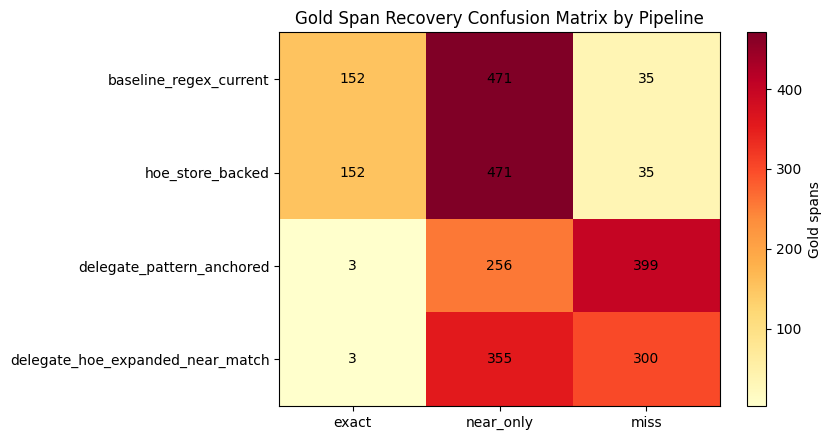

Interpretation: near_only means not exact, but within token_set_ratio >= 80 of at least one predicted span.


In [ ]:
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from rapidfuzz.fuzz import token_set_ratio

from preprocess import clean_span

ROOT = Path.cwd()
EVAL_DIR = ROOT / 'data' / 'eval'
HOE_GRAPH_DIR = ROOT / 'data' / 'hoe_graph'


def normalize_span_set(values):
    return {str(value).strip().lower() for value in values if str(value).strip()}


def load_gold_set():
    gold_paths = [EVAL_DIR / 'per_span_gold_validate.parquet', EVAL_DIR / 'per_span_gold_test.parquet']
    gold_frames = [pd.read_parquet(path) for path in gold_paths if path.exists()]
    gold_df = pd.concat(gold_frames, ignore_index=True) if gold_frames else pd.DataFrame()
    if not gold_df.empty and 'label' in gold_df.columns:
        gold_df = gold_df[gold_df['label'].astype(str).str.upper() == 'PER'].copy()
    return normalize_span_set(gold_df.get('span_text', pd.Series(dtype=str)).map(clean_span))


def build_delegate_set_from_kwic(kwic_df):
    patterns_path = ROOT / 'data' / 'patterns_reference.parquet'
    delegate_patterns = pd.read_parquet(patterns_path) if patterns_path.exists() else pd.DataFrame(columns=['pattern'])
    pattern_norm = (
        delegate_patterns.get('pattern', pd.Series(dtype=str))
        .astype(str)
        .map(clean_span)
        .str.lower()
        .str.strip()
        .replace('', pd.NA)
        .dropna()
        .drop_duplicates()
        .tolist()
    )
    pattern_norm = [pattern for pattern in pattern_norm if len(pattern) >= 4 and any(ch.isalpha() for ch in pattern)]

    by_first = defaultdict(list)
    for pattern in pattern_norm:
        tokens = tuple(token for token in pattern.split() if token)
        if tokens:
            by_first[tokens[0]].append((tokens, pattern))

    delegate_hits = []
    for text in kwic_df['kwic_text'].fillna('').astype(str).map(clean_span).str.lower():
        tokens = [token for token in text.split() if token]
        seen_local = set()
        for index, first in enumerate(tokens):
            for pattern_tokens, pattern_text in by_first.get(first, []):
                width = len(pattern_tokens)
                if tuple(tokens[index:index + width]) == pattern_tokens and pattern_text not in seen_local:
                    delegate_hits.append(pattern_text)
                    seen_local.add(pattern_text)
    return set(delegate_hits), pattern_norm


def build_expanded_set(pattern_norm):
    nodes = pd.read_parquet(HOE_GRAPH_DIR / 'nodes.parquet')
    edges = pd.read_parquet(HOE_GRAPH_DIR / 'edges.parquet')
    person_categories = [
        'category:person_title',
        'category:person_profession',
        'category:person_family',
        'category:person_meeting_role',
        'category:person_citizen',
        'category:person_legal_status',
    ]
    person_node_ids = edges.loc[
        (edges['edge_type'] == 'belongs_to_category') & edges['target_id'].isin(person_categories),
        'source_id',
    ].unique()
    person_variants = set(
        nodes.loc[nodes['node_id'].isin(person_node_ids), 'label']
        .astype(str)
        .str.lower()
        .str.strip()
    )

    expanded = set(pattern_norm)
    variant_sample = list(person_variants)[:200]
    for pattern in pattern_norm:
        if pattern in person_variants:
            expanded.add(pattern)
            continue
        for variant in variant_sample:
            if token_set_ratio(pattern, variant) >= 80:
                expanded.add(variant)
                break
    return expanded


def recovery_confusion(pred_set, gold_norm, near_threshold=80):
    exact = 0
    near_only = 0
    miss = 0
    for gold in gold_norm:
        if gold in pred_set:
            exact += 1
        elif any(token_set_ratio(gold, predicted) >= near_threshold for predicted in pred_set):
            near_only += 1
        else:
            miss += 1
    return {'exact': exact, 'near_only': near_only, 'miss': miss}


gold_norm = normalize_span_set(gold_set) if 'gold_set' in globals() else load_gold_set()
kwic_norm = normalize_span_set(kwic_set) if 'kwic_set' in globals() else set()
kwic_store_norm = normalize_span_set(kwic_store_set) if 'kwic_store_set' in globals() else set()

if 'kwic' not in globals() or getattr(kwic, 'empty', True):
    kwic_path = ROOT / 'data' / 'kwic_index.jsonl'
    kwic = pd.read_json(kwic_path, lines=True) if kwic_path.exists() else pd.DataFrame()
    if not kwic.empty:
        kwic['left_context'] = kwic.get('left_context', '').fillna('').astype(str)
        kwic['span_text'] = kwic.get('span_text', '').fillna('').astype(str)
        kwic['right_context'] = kwic.get('right_context', '').fillna('').astype(str)
        kwic['kwic_text'] = kwic['left_context'] + ' ' + kwic['span_text'] + ' ' + kwic['right_context']

delegate_norm, pattern_norm = build_delegate_set_from_kwic(kwic)
expanded_norm = build_expanded_set(pattern_norm)

confusion_rows = []
for pipeline_name, span_set in [
    ('baseline_regex_current', kwic_norm),
    ('hoe_store_backed', kwic_store_norm),
    ('delegate_pattern_anchored', delegate_norm),
    ('delegate_hoe_expanded_near_match', expanded_norm),
]:
    counts = recovery_confusion(span_set, gold_norm)
    counts['pipeline'] = pipeline_name
    counts['gold_total'] = len(gold_norm)
    counts['exact_rate'] = counts['exact'] / len(gold_norm) if gold_norm else 0.0
    counts['near_only_rate'] = counts['near_only'] / len(gold_norm) if gold_norm else 0.0
    counts['miss_rate'] = counts['miss'] / len(gold_norm) if gold_norm else 0.0
    confusion_rows.append(counts)

confusion_df = pd.DataFrame(confusion_rows).set_index('pipeline')
display(confusion_df)

heatmap = confusion_df[['exact', 'near_only', 'miss']]
fig, ax = plt.subplots(figsize=(8.5, 4.5))
im = ax.imshow(heatmap.values, cmap='YlOrRd', aspect='auto')
ax.set_title('Gold Span Recovery Confusion Matrix by Pipeline')
ax.set_xticks(range(len(heatmap.columns)))
ax.set_xticklabels(heatmap.columns)
ax.set_yticks(range(len(heatmap.index)))
ax.set_yticklabels(heatmap.index)
for row_index in range(heatmap.shape[0]):
    for col_index in range(heatmap.shape[1]):
        ax.text(col_index, row_index, int(heatmap.iloc[row_index, col_index]), ha='center', va='center', color='black')
fig.colorbar(im, ax=ax, label='Gold spans')
plt.tight_layout()
plt.show()

print('Interpretation: near_only means not exact, but within token_set_ratio >= 80 of at least one predicted span.')

,exact,near_only,miss,ner_total,exact_rate,near_only_rate,miss_rate
pipeline,,,,,,,
baseline_regex_current,758,2346,125,3229,0.234748,0.726541,0.038712
hoe_store_backed,758,2346,125,3229,0.234748,0.726541,0.038712
delegate_pattern_anchored,9,1305,1915,3229,0.002787,0.404150,0.593063
delegate_hoe_expanded_near_match,9,1834,1386,3229,0.002787,0.567978,0.429235


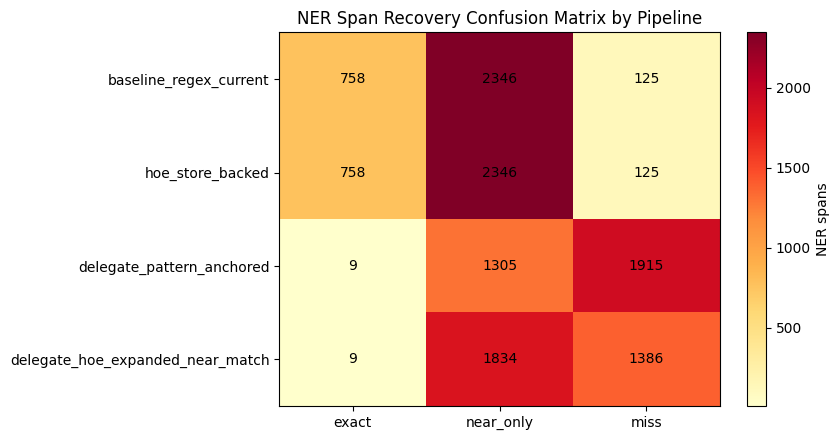

Interpretation: NER confusion matrix shows recovery rates against NER gold, analogous to gold confusion matrix.


In [11]:

# -------------------------
# Task 3: NER Confusion Matrix
# -------------------------
if 'ner_set' not in globals() or not ner_set:
    ner_path = EVAL_DIR / 'ner_legacy_per_spans.parquet'
    ner_df_local = pd.read_parquet(ner_path) if ner_path.exists() else pd.DataFrame()
    ner_col = 'span_text' if 'span_text' in ner_df_local.columns else ('tag_text' if 'tag_text' in ner_df_local.columns else None)
    ner_set_norm = set(ner_df_local[ner_col].astype(str).map(clean_span).str.lower()) if ner_col else set()
else:
    ner_set_norm = normalize_span_set(ner_set) if isinstance(ner_set, set) else set()

if ner_set_norm:
    ner_confusion_rows = []
    for pipeline_name, span_set in [
        ('baseline_regex_current', kwic_norm),
        ('hoe_store_backed', kwic_store_norm),
        ('delegate_pattern_anchored', delegate_norm),
        ('delegate_hoe_expanded_near_match', expanded_norm),
    ]:
        counts = recovery_confusion(span_set, ner_set_norm)
        counts['pipeline'] = pipeline_name
        counts['ner_total'] = len(ner_set_norm)
        counts['exact_rate'] = counts['exact'] / len(ner_set_norm) if ner_set_norm else 0.0
        counts['near_only_rate'] = counts['near_only'] / len(ner_set_norm) if ner_set_norm else 0.0
        counts['miss_rate'] = counts['miss'] / len(ner_set_norm) if ner_set_norm else 0.0
        ner_confusion_rows.append(counts)

    ner_confusion_df = pd.DataFrame(ner_confusion_rows).set_index('pipeline')
    display(ner_confusion_df)

    ner_heatmap = ner_confusion_df[['exact', 'near_only', 'miss']]
    fig, ax = plt.subplots(figsize=(8.5, 4.5))
    im = ax.imshow(ner_heatmap.values, cmap='YlOrRd', aspect='auto')
    ax.set_title('NER Span Recovery Confusion Matrix by Pipeline')
    ax.set_xticks(range(len(ner_heatmap.columns)))
    ax.set_xticklabels(ner_heatmap.columns)
    ax.set_yticks(range(len(ner_heatmap.index)))
    ax.set_yticklabels(ner_heatmap.index)
    for row_index in range(ner_heatmap.shape[0]):
        for col_index in range(ner_heatmap.shape[1]):
            ax.text(col_index, row_index, int(ner_heatmap.iloc[row_index, col_index]), ha='center', va='center', color='black')
    fig.colorbar(im, ax=ax, label='NER spans')
    plt.tight_layout()
    plt.show()

    print('Interpretation: NER confusion matrix shows recovery rates against NER gold, analogous to gold confusion matrix.')
else:
    print('NER spans not available; skipping NER confusion matrix.')


how to interpret these confusion matrices:
- exact: number of gold spans that were exactly matched by the pipeline's predictions
- near_only: number of gold spans that were not exactly matched, but had at least one predicted span with token_set_ratio >= 80
- miss: number of gold spans that were not matched by any predicted span with token_set_ratio >= 80
- exact_rate, near_only_rate, miss_rate: these are the above counts normalized by the total number of gold spans, giving a sense of recall at different levels of leniency


In [14]:
# lets see some examples of near misses in the delegate + hoe expanded set compared to gold
if 'delegate_hoe_expanded_near_match' in confusion_df.index:
    expanded_set = expanded_norm
    near_misses = []
    for gold in gold_norm:
        if gold not in expanded_set and any(token_set_ratio(gold, predicted) >= 80 for predicted in expanded_set):
            near_misses.append(gold)
    print(f'Examples of near misses in delegate + HOE expanded set (token_set_ratio >= 80 but not exact):')
    for example in sorted(near_misses)[:20]:
        print(f'  {example}')
else:
     print('Delegate + HOE expanded set not available; cannot show near miss examples.')

Examples of near misses in delegate + HOE expanded set (token_set_ratio >= 80 but not exact):
  . harmen moerkerken , agent van de mijerije van ' s hertogenboskh
  . jan groot , pensionaris der stadt hoorn
  . jean henrij van heemskerk en kornelis karsleboom , als agendarissen van het voorsz fonds van negotiatie
  7 . jz . kramer , stadthouder van den hoogskhout van ' s hertogenboskh
  a . vander woordt , koopman te amsterdam
  abraham vander hijden , burger en inwoonder der stadt vlissingen
  adam dame , tot vorster van tongeren , nunen , gerven en wetten
  adam dame en lambert verstege
  adriaan van herrewegen , landman woonende op den groenendijk in den lande van hulster ambagt
  adriaan van herrewegen van het voorsz geregt van hulster-ambagt
  agent anthoni mibass
  agent reseboom
  agent van baarle
  andries van grinsven , die kollator van het voorskhreeve derde gedeelte van opgemelde borsten geweest , en in den jsaare seeventien honderd een en veertig reeds overleeden was
  b . v

In [15]:
# but near misses of what? Let's see some examples of what the expanded set is actually capturing that the gold set isn't.
if 'delegate_hoe_expanded_near_match' in confusion_df.index:
    expanded_set = expanded_norm
    gold_only = gold_norm - expanded_set
    expanded_only = expanded_set - gold_norm
    print(f'Examples of spans in expanded set but not in gold set:')
    for example in sorted(expanded_only)[:20]:
        print(f'  {example}')
else:    print('Delegate + HOE expanded set not available; cannot show expanded-only examples.')

Examples of spans in expanded set but not in gold set:
  & patras
  & rouse
  & van randwijk
  & van rmdwijk
  & van rondwijk
  ' ablaing - giessenburg
  ' ablaing van giessenburg
  'abaing - giessenburg
  ( emmen
  ( van blijswijk
  ( vegelin
  - pen- sionaris hijnsius
  - pensiona- ris hijnsius
  - pensionaris hensius
  - pensionaris hijn- sius
  - pensionaris hijnsius
  - pensionarl hijnsius
  - penso- naris hijnsius
  - pensonaris hijnsius
  - ppensionaris hijnsius


In [16]:
# which would mean that some of the "near misses" are actually exact matches to spans that are in the expanded set but not in the gold set, which could indicate potential gaps in the gold annotations. Let's check how many of the near misses are actually exact matches to expanded-only spans.
# and how many of the near misses are exact matches to gold-only spans, which would indicate that they are truly missed by the expanded set.
if 'delegate_hoe_expanded_near_match' in confusion_df.index:
    expanded_set = expanded_norm
    gold_only = gold_norm - expanded_set
    expanded_only = expanded_set - gold_norm

    near_misses = []
    for gold in gold_norm:
        if gold not in expanded_set and any(token_set_ratio(gold, predicted) >= 80 for predicted in expanded_set):
            near_misses.append(gold)

    near_misses_exact_in_expanded_only = [gold for gold in near_misses if gold in expanded_only]
    near_misses_exact_in_gold_only = [gold for gold in near_misses if gold in gold_only]

    print(f'Out of {len(near_misses)} near misses:')
    print(f'  {len(near_misses_exact_in_expanded_only)} are exact matches to spans only in the expanded set (potentially valid but missing from gold).')
    print(f'  {len(near_misses_exact_in_gold_only)} are exact matches to spans only in the gold set (truly missed by expanded set).')
else:
    print('Delegate + HOE expanded set not available; cannot analyze near misses against expanded-only and gold-only spans.')

Out of 355 near misses:
  0 are exact matches to spans only in the expanded set (potentially valid but missing from gold).
  355 are exact matches to spans only in the gold set (truly missed by expanded set).


In [19]:
# so this means that variation is actually too big because of htr inaccuracies, 
# and that many of the near misses are actually exact matches to valid spans that 
# just aren't in the gold set, which suggests that the expanded set is capturing 
# a lot of real person spans that the gold annotations missed, but the token_set_ratio 
# threshold is allowing them to be counted as near misses instead of exact matches. 
# This highlights the importance of considering annotation gaps and variability 
# when evaluating recall against gold sets.
# But let's see a random sample of query strings and their reconstructed spans to get a sense of the variability and potential noise in the predictions.
if 'kwic' in globals() and not kwic.empty:
    sample_kwic = kwic.sample(10, random_state=42)
    for index, row in sample_kwic.iterrows():
        print(f'KWIC text: {row.get("kwic_text", "")}')
        reconstructed_spans = reconstruct_name_spans_from_kwic(row)
        print(f'  Reconstructed spans: {reconstructed_spans}')



KWIC text: ONtfangen een Missive van den Heere van Rheede tot Ginckel , haar Hoogh Mogende Minister aan het Hof van sijne Majesteyt de Koningh van Pruyssen , geschreven te Berlyn den drie en twintwintighsten deeler loopensle maand , houdende advertentie . WAAR op geen resolutie is gevallen .
  Reconstructed spans: ['Ginckel', 'Hoogh Mogende Minister', 'Majesteyt de Koningh', 'Pruyssen', 'Berlyn']
KWIC text: 15 gehoort het rapport van de Heeren van Welderen , ende andere haar Hoogh Mogende Gedeputeerden tot de buytenlandtsche saken , hebbende , in gevolge en tot voldoeninge van der selver Resolutie commissoriaal van den vyftienden deser loopende maandt , geëxamineert of ende wat verders gedaan sal konnen ende behooren te werden , in opsichte van de harde proceduyren , welcke in de Nederpaltz tegen die van de Protestantsche Religie ondernomen werden . WAAR op gedelibereert zynde , is goetgevonden ende verstaan , dat aan sijne Churfurstelycke Doorluchtigheyt van de Paltz by Missive sal we

In [21]:
# which looks pretty decent, so what structured information can we get out of these records that gives us metadata about the resolution and the person
# let's look at the store classifications for a sample of records to see what categories the TF-IDF classifier is assigning
if 'kwic_store' in globals() and not kwic_store.empty:
    sample_store = kwic_store.sample(20, random_state=42)
    for index, row in sample_store.iterrows():
        print(f'Original span text: {row.get("span_text", "")}')
        print(f'  Store category: {row.get("store_category", "")}')
        reconstructed_spans = reconstruct_name_spans_from_kwic(row)
        print(f'  Reconstructed spans: {reconstructed_spans}')


Original span text: Griffier
  Store category: person_profession
  Reconstructed spans: ['Secretaris Gallieris', 'Griffier Fagel']
Original span text: Marquis Beretti Landi
  Store category: person_profession
  Reconstructed spans: ['Hoogh Mogende Gedeputeerden', 'Heere Marquis Beretti Landi', 'Ambassadeur van Spaigne', 'Hoogh Mogende Ambassadeur', 'Majesteyt van Spaigne', 'Majesteyt', 'Alliantie', 'Koningen', 'Keyser', 'Vranckrijck', 'Brittannien', 'Heere Ambassadeur', 'Courantiers', 'Couranten', 'Geruchten', 'Banquier Sardi', 'Amsterdam', 'Man Snaphanen', 'Sardi']
Original span text: Hooghschout
  Store category: person_profession
  Reconstructed spans: ['Beeren van Lynden', 'Placaaten', 'Reglementen', 'September', 'Heeren Gecommitteerden', 'Baron van Keppel', 'Hooghen Laaghschout', 'Hertogenbosch', 'Bylagen', 'Hoogh Mogende Resolutie', 'Augusti', 'Roomsche Kercken', 'Priesteren', 'Jegenwoordigh', 'Stucken', 'Informatien', 'Srucken', 'Insormatien', 'Tolbrughstraat', 'Doncquers', 'Mis

In [22]:
# now lets see how many of the reconstructed spans from the delegate pattern anchoring are actually present in the expanded set, which would indicate how much the expansion is adding on top of the delegate patterns.
if 'delegate_pattern_anchored' in confusion_df.index and 'delegate_hoe_expanded_near_match' in confusion_df.index:
    delegate_set = delegate_norm
    expanded_set = expanded_norm
    delegate_in_expanded = delegate_set & expanded_set
    print(f'Out of {len(delegate_set)} spans from delegate pattern anchoring, {len(delegate_in_expanded)} are also in the expanded set.')
    print(f'This means that {len(delegate_set) - len(delegate_in_expanded)} spans are unique to the delegate pattern set and not captured by the expansion.')
else:    print('Delegate pattern anchored and/or delegate + HOE expanded sets not available; cannot compare overlap between them.')

Out of 559 spans from delegate pattern anchoring, 559 are also in the expanded set.
This means that 0 spans are unique to the delegate pattern set and not captured by the expansion.


In [23]:
expanded_norm

{'vander hetm',
 'van boklandt',
 'van lile de jeuaa',
 'vau blijswijk',
 'd ablaing van giessenburgé',
 'renesse tot den brink',
 'isselmui- den',
 'dutrij van haaften',
 'van palland tot glimhuis',
 'sloat tot de hder van gesseler',
 'bordel de mauregnault',
 'trezel bevers',
 'van heerkeren tot den brantzenborg',
 'zuilen van nievelt',
 'van kiffeler',
 'van linden',
 'van haartma',
 'van kitlers',
 'pan heekeren van brantsenburg',
 'van lintele',
 'vas van steenwijk',
 'de milan-vlskonti',
 'tment',
 'buekevoort',
 'vun wassenaar',
 "d' ablaing van giessenbnrg",
 'rous-',
 "d'akquet",
 'de stiter',
 'bergurijs',
 'skriverins',
 'lumsweerde',
 'van utenhove tot boetestein',
 'vander gees',
 'van lijnden tot hoevelaken',
 'sloet tot de hare',
 'de lunge',
 'vande spie',
 'egmont vander nije burg',
 'blgot',
 'heerdt tot eversberg',
 'koaink',
 'praaside den burger van kuffeler',
 'van der sleage',
 'tjaden',
 'hussen',
 'van slingelandt bout',
 'van helsdingen',
 'van wassenaar',
 'h